# Deep Analysis: Trading Bot Performance & Model Diagnostics

Comprehensive analysis of 138 resolved trades, XGBoost model internals, live game snapshots, and sub-model decomposition.

In [20]:
# ── Imports & Global Config ──────────────────────────────────────────────────
%pip install xgboost
import sqlite3, json, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import xgboost as xgb
from pathlib import Path

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (14, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "font.family": "sans-serif",
})

# Color palette
GREEN  = "#22c55e"
RED    = "#ef4444"
BLUE   = "#3b82f6"
PURPLE = "#a78bfa"
YELLOW = "#facc15"
ORANGE = "#f97316"

BASE = Path("/Users/masamiyoshida/Documents/unihack")
print("Imports OK")

Note: you may need to restart the kernel to use updated packages.
Imports OK


In [21]:
# ── Load Data ────────────────────────────────────────────────────────────────
# Trades database
conn_trades = sqlite3.connect(BASE / "trades.sqlite")
trades_all = pd.read_sql("SELECT * FROM simulated_trades", conn_trades)
conn_trades.close()

# Live observations database
conn_obs = sqlite3.connect(BASE / "live_observations.sqlite")
snapshots = pd.read_sql("SELECT * FROM snapshots", conn_obs)
conn_obs.close()

# Resolved trades (pnl is not null and not zero)
trades = trades_all[(trades_all["pnl"].notna()) & (trades_all["pnl"] != 0)].copy()
trades["won"] = (trades["pnl"] > 0).astype(int)
trades["timestamp"] = pd.to_datetime(trades["timestamp"])
snapshots["recorded_at"] = pd.to_datetime(snapshots["recorded_at"])

# Feature lists
live_features = json.load(open(BASE / "data" / "v4_live_features.json"))
pregame_features = json.load(open(BASE / "data" / "v4_pregame_features.json"))
edge_features = json.load(open(BASE / "data" / "v4_edge_features.json"))
all_features = live_features  # win_prob and margin models use live_features (255)

print(f"Total trades in DB:     {len(trades_all)}")
print(f"Resolved trades:        {len(trades)}")
print(f"Live snapshots:         {len(snapshots)}")
print(f"Unique games (trades):  {trades['game_id'].nunique()}")
print(f"Unique games (snaps):   {snapshots['game_id'].nunique()}")
print(f"Live features:          {len(live_features)}")
print(f"Pregame features:       {len(pregame_features)}")
print(f"Edge features:          {len(edge_features)}")

Total trades in DB:     511
Resolved trades:        215
Live snapshots:         12081
Unique games (trades):  34
Unique games (snaps):   59
Live features:          255
Pregame features:       160
Edge features:          259


---
## Section 1: Resolved Trade Log & Calibration Curve

Display all 138 resolved trades and build a calibration curve to assess how well the model's predicted probabilities match actual win rates.

In [22]:
# ── Section 1: Resolved Trade Log ────────────────────────────────────────────
display_cols = [
    "timestamp", "game_id", "target_team", "action",
    "model_implied_prob", "market_implied_prob", "bought_home",
    "home_score", "away_score", "period", "secs_left", "pnl", "won",
]
trades_display = trades[display_cols].copy()
trades_display["timestamp"] = trades_display["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S")
trades_display["game_id"] = trades_display["game_id"].str[:10] + "..."
trades_display["pnl"] = trades_display["pnl"].round(2)
trades_display["model_implied_prob"] = trades_display["model_implied_prob"].round(4)
trades_display["market_implied_prob"] = trades_display["market_implied_prob"].round(4)

pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 200)

print(f"{'='*80}")
print(f"  RESOLVED TRADE LOG  —  {len(trades)} trades")
print(f"{'='*80}")
print(f"  Total PnL:    ${trades['pnl'].sum():,.2f}")
print(f"  Win rate:     {trades['won'].mean()*100:.1f}%")
print(f"  Avg PnL/trade: ${trades['pnl'].mean():,.2f}")
print(f"  Max win:      ${trades['pnl'].max():,.2f}")
print(f"  Max loss:     ${trades['pnl'].min():,.2f}")
print(f"{'='*80}\n")

trades_display

  RESOLVED TRADE LOG  —  215 trades
  Total PnL:    $277.17
  Win rate:     51.6%
  Avg PnL/trade: $1.29
  Max win:      $221.67
  Max loss:     $-46.88



,timestamp,game_id,target_team,action,model_implied_prob,market_implied_prob,bought_home,home_score,away_score,period,secs_left,pnl,won
9,2026-03-15 04:05:30,0x671b141d...,Clippers,SELL(TRAILING_STOP(peak 0.540 now 0.490)),0.1644,0.49,0,NaN,NaN,NaN,NaN,24.24,1
11,2026-03-15 04:20:57,0x671b141d...,Clippers,SELL(TRAILING_STOP(peak 0.730 now 0.670)),0.1305,0.67,0,NaN,NaN,NaN,NaN,18.37,1
14,2026-03-15 04:36:18,0x671b141d...,Clippers,SELL(EDGE_FLIP(was -0.192 now +0.060)),0.1698,0.89,0,NaN,NaN,NaN,NaN,16.42,1
16,2026-03-15 04:38:12,0x671b141d...,Clippers,SELL(TRAILING_STOP(peak 0.240 now 0.180)),0.2503,0.18,1,NaN,NaN,NaN,NaN,31.82,1
18,2026-03-15 04:41:19,0x671b141d...,Clippers,SELL(EDGE_FLIP(was +0.070 now -0.050)),0.1698,0.22,1,NaN,NaN,NaN,NaN,11.11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,2026-03-22 04:16:01,0x21a3b5f6...,Suns,SELL(STOP_LOSS(entry 0.430 now 0.260)),0.6082,0.26,1,97.0,100.0,4.0,154.0,-19.77,0
504,2026-03-22 04:16:46,0x21a3b5f6...,Suns,SELL(EDGE_FLIP(was +0.348 now -0.051)),0.4587,0.51,1,100.0,102.0,4.0,133.0,48.08,1
506,2026-03-22 04:17:52,0x21a3b5f6...,Suns,SELL(EDGE_FLIP(was -0.061 now +0.053)),0.4731,0.42,0,100.0,102.0,4.0,133.0,10.42,1
508,2026-03-22 04:18:54,0x21a3b5f6...,Suns,SELL(TRAILING_STOP(peak 0.570 now 0.490)),0.5544,0.49,1,101.0,102.0,4.0,133.0,8.33,1


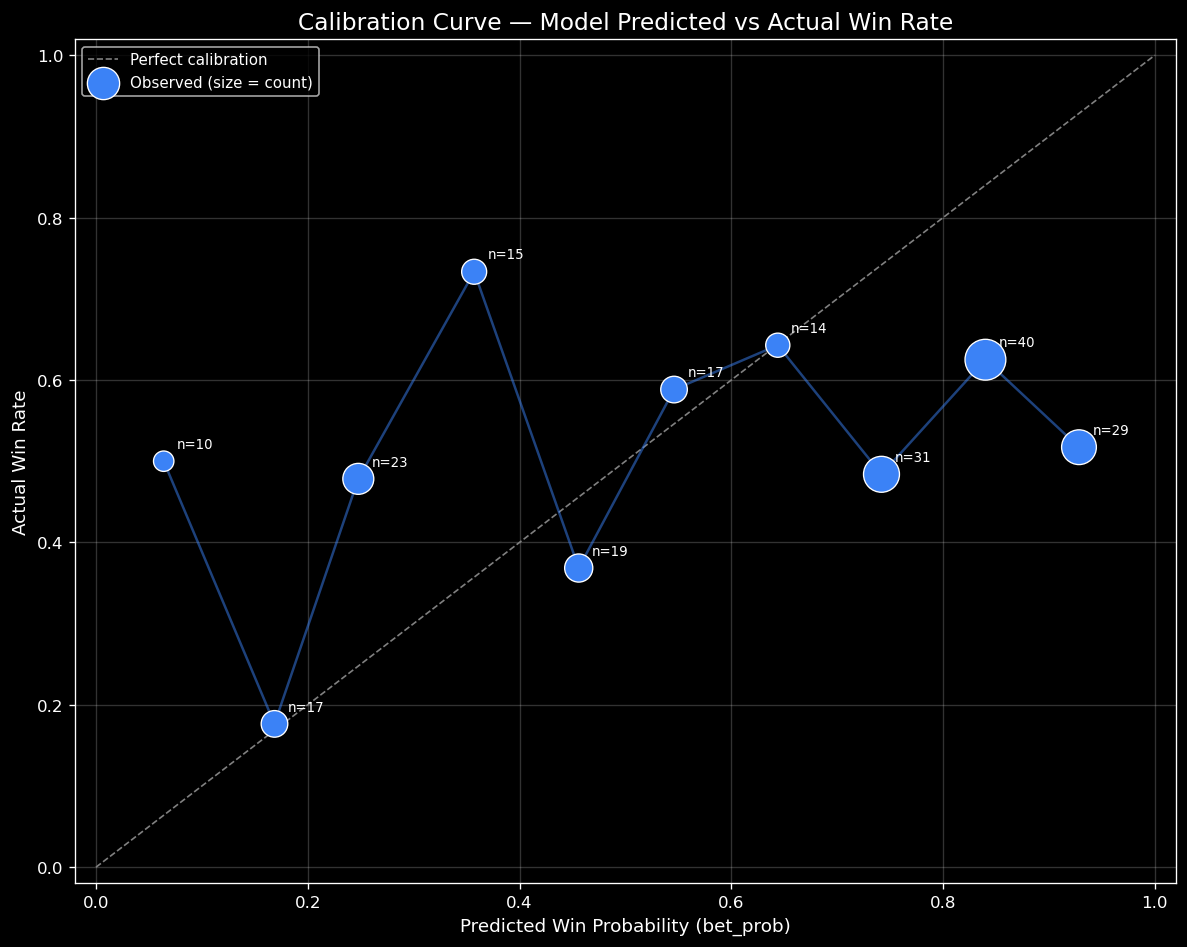


  CALIBRATION TABLE
  Bin                     Count  Pred Mean  Actual WR
  ------------------------------------------------------------
  (0.0124, 0.11]             10     0.0639     0.5000
  (0.11, 0.207]              17     0.1686     0.1765
  (0.207, 0.303]             23     0.2477     0.4783
  (0.303, 0.4]               15     0.3572     0.7333
  (0.4, 0.497]               19     0.4559     0.3684
  (0.497, 0.594]             17     0.5459     0.5882
  (0.594, 0.69]              14     0.6439     0.6429
  (0.69, 0.787]              31     0.7418     0.4839
  (0.787, 0.884]             40     0.8400     0.6250
  (0.884, 0.98]              29     0.9284     0.5172


In [23]:
# ── Section 1: Calibration Curve ─────────────────────────────────────────────
# model_implied_prob is raw P(home wins).
# For away bets (bought_home=0): bet_prob = 1 - model_implied_prob
# For home bets (bought_home=1): bet_prob = model_implied_prob
trades_cal = trades.copy()
trades_cal["bet_prob"] = np.where(
    trades_cal["bought_home"] == 1,
    trades_cal["model_implied_prob"],
    1 - trades_cal["model_implied_prob"],
)

# Bin into 10 bins
trades_cal["prob_bin"] = pd.cut(trades_cal["bet_prob"], bins=10)
cal_table = trades_cal.groupby("prob_bin", observed=False).agg(
    count=("won", "size"),
    predicted_mean=("bet_prob", "mean"),
    actual_win_rate=("won", "mean"),
).reset_index()
cal_table = cal_table[cal_table["count"] > 0]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Perfect calibration")
ax.scatter(
    cal_table["predicted_mean"], cal_table["actual_win_rate"],
    s=cal_table["count"] * 15, color=BLUE, edgecolors="white", linewidth=0.8,
    zorder=5, label="Observed (size = count)",
)
ax.plot(cal_table["predicted_mean"], cal_table["actual_win_rate"],
        color=BLUE, alpha=0.5, linewidth=1.5)

for _, row in cal_table.iterrows():
    ax.annotate(
        f"n={int(row['count'])}",
        (row["predicted_mean"], row["actual_win_rate"]),
        textcoords="offset points", xytext=(8, 8), fontsize=8, color="white",
    )

ax.set_xlabel("Predicted Win Probability (bet_prob)")
ax.set_ylabel("Actual Win Rate")
ax.set_title("Calibration Curve — Model Predicted vs Actual Win Rate")
ax.legend(loc="upper left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Print calibration table
print("\n  CALIBRATION TABLE")
print("  " + "=" * 60)
print(f"  {'Bin':<22} {'Count':>6} {'Pred Mean':>10} {'Actual WR':>10}")
print("  " + "-" * 60)
for _, row in cal_table.iterrows():
    print(f"  {str(row['prob_bin']):<22} {int(row['count']):>6} {row['predicted_mean']:>10.4f} {row['actual_win_rate']:>10.4f}")
print("  " + "=" * 60)

---
## Section 2: XGBoost Feature Importances

Load all 4 XGBoost sub-models (win_probability, margin, market_proxy, edge_model), extract feature importance by gain, and compare which features drive each model.

In [24]:
# ── Section 2: XGBoost Feature Importances ───────────────────────────────────
model_configs = {
    "win_probability": {"file": "v4_win_probability.json", "features": live_features},
    "margin":          {"file": "v4_margin.json",          "features": live_features},
    "market_proxy":    {"file": "v4_market_proxy.json",    "features": pregame_features},
    "edge_model":      {"file": "v4_edge_model.json",      "features": edge_features},
}

importances = {}
for name, cfg in model_configs.items():
    booster = xgb.Booster()
    booster.load_model(str(BASE / "data" / cfg["file"]))
    raw_scores = booster.get_score(importance_type="gain")
    # Map f0, f1, ... back to real feature names
    feat_names = cfg["features"]
    mapped = {}
    for key, val in raw_scores.items():
        idx = int(key.replace("f", ""))
        if idx < len(feat_names):
            mapped[feat_names[idx]] = val
        else:
            mapped[key] = val
    importances[name] = pd.Series(mapped).sort_values(ascending=False)
    print(f"  {name:20s}: {len(mapped)} features with importance, top = {importances[name].index[0]} ({importances[name].iloc[0]:.1f})")

print("\nAll models loaded successfully.")

  win_probability     : 246 features with importance, top = MARGIN (568.4)
  margin              : 252 features with importance, top = MARGIN_X_PROGRESS (37582.5)
  market_proxy        : 154 features with importance, top = DIFF_STATIC_NET_RATING_FADED (996.0)
  edge_model          : 244 features with importance, top = ABS_MARGIN_OVER_SQRT_TIME (242.2)

All models loaded successfully.


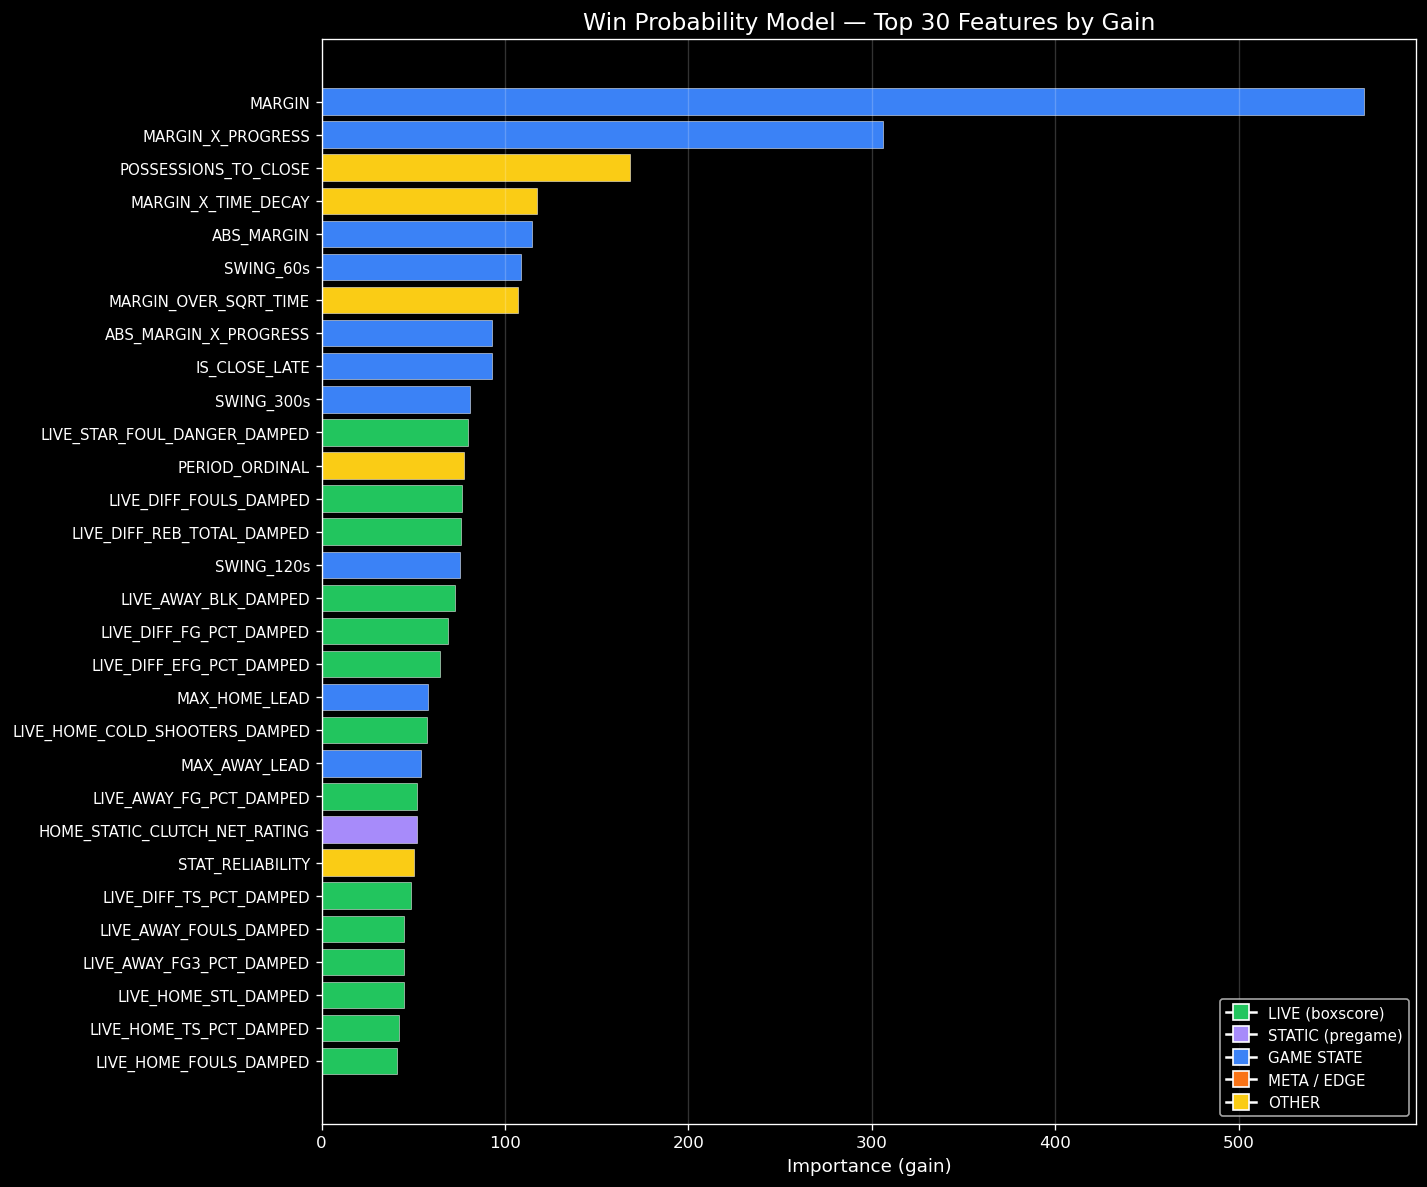

In [25]:
# ── Top 30 features for win_probability model (horizontal bar chart) ─────────
wp = importances["win_probability"].head(30)

def classify_feature(name):
    if name.startswith("LIVE_"):
        return "LIVE (boxscore)"
    elif "STATIC" in name or name.startswith("HOME_ROLL") or name.startswith("AWAY_ROLL") or name.startswith("DIFF_ROLL") or "REST" in name or "B2B" in name or "FATIGUE" in name or "STREAK" in name or "TRAJECTORY" in name or "GAMES_LAST" in name or "FORM" in name:
        return "STATIC (pregame)"
    elif name in ("MARGIN", "PERIOD", "GAME_SECONDS_LEFT", "GAME_PROGRESS", "QUARTER_PROGRESS",
                  "ABS_MARGIN", "TOTAL_POINTS", "SCORING_PACE", "MARGIN_X_PROGRESS",
                  "ABS_MARGIN_X_PROGRESS", "IS_Q4", "IS_CLOSE_LATE", "IS_BLOWOUT", "IS_CLUTCH",
                  "MAX_HOME_LEAD", "MAX_AWAY_LEAD", "LEAD_VOLATILITY", "LEAD_CHANGES",
                  "LAG_MARGIN", "MARGIN_CHANGE", "LAG_SCORING_PACE", "PACE_CHANGE",
                  "HOME_SCORE", "AWAY_SCORE", "ABS_MARGIN_OVER_SQRT_TIME"):
        return "GAME STATE"
    elif name.startswith("HOME_MOM") or name.startswith("AWAY_MOM") or name.startswith("SWING"):
        return "GAME STATE"
    elif name in ("EDGE", "ABS_EDGE", "OOF_PROXY_PROB", "OOF_LIVE_PROB"):
        return "META / EDGE"
    else:
        return "OTHER"

cat_colors = {
    "LIVE (boxscore)": GREEN,
    "STATIC (pregame)": PURPLE,
    "GAME STATE": BLUE,
    "META / EDGE": ORANGE,
    "OTHER": YELLOW,
}

fig, ax = plt.subplots(figsize=(12, 10))
colors = [cat_colors.get(classify_feature(f), "white") for f in wp.index]
bars = ax.barh(range(len(wp)), wp.values, color=colors, edgecolor="white", linewidth=0.3)
ax.set_yticks(range(len(wp)))
ax.set_yticklabels(wp.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Importance (gain)")
ax.set_title("Win Probability Model — Top 30 Features by Gain")
legend_elements = [Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=10, label=k)
                   for k, c in cat_colors.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [26]:
# ── Comparison table: top 15 features across all 4 models ────────────────────
top_n = 15
model_names = list(importances.keys())

# Collect union of top-15 from each model
all_top = set()
for name in model_names:
    all_top.update(importances[name].head(top_n).index.tolist())

# Build comparison DataFrame
comp_data = []
for feat in sorted(all_top):
    row = {"feature": feat, "category": classify_feature(feat)}
    for mname in model_names:
        row[mname] = importances[mname].get(feat, 0)
    comp_data.append(row)

comp_df = pd.DataFrame(comp_data)
comp_df = comp_df.sort_values("win_probability", ascending=False).head(20)

print("  TOP FEATURES ACROSS ALL 4 MODELS (sorted by win_probability importance)")
print("  " + "=" * 110)
print(f"  {'Feature':<35} {'Category':<18} {'WinProb':>10} {'Margin':>10} {'MktProxy':>10} {'Edge':>10}")
print("  " + "-" * 110)
for _, row in comp_df.iterrows():
    print(f"  {row['feature']:<35} {row['category']:<18} {row['win_probability']:>10.1f} {row['margin']:>10.1f} {row['market_proxy']:>10.1f} {row['edge_model']:>10.1f}")
print("  " + "=" * 110)

# Category breakdown
print("\n  FEATURE CATEGORY BREAKDOWN (win_probability model, all features):")
wp_all = importances["win_probability"]
cats = pd.Series([classify_feature(f) for f in wp_all.index])
cat_imp = pd.DataFrame({"feature": wp_all.index, "importance": wp_all.values, "category": cats.values})
cat_summary = cat_imp.groupby("category").agg(
    count=("importance", "size"),
    total_gain=("importance", "sum"),
    avg_gain=("importance", "mean"),
).sort_values("total_gain", ascending=False)
print(cat_summary.to_string())

  TOP FEATURES ACROSS ALL 4 MODELS (sorted by win_probability importance)
  Feature                             Category              WinProb     Margin   MktProxy       Edge
  --------------------------------------------------------------------------------------------------------------
  MARGIN                              GAME STATE              568.4    30641.3        0.0       40.2
  MARGIN_X_PROGRESS                   GAME STATE              306.2    37582.5        0.0       21.1
  POSSESSIONS_TO_CLOSE                OTHER                   168.2    32091.1        0.0       63.8
  MARGIN_X_TIME_DECAY                 OTHER                   117.2    14901.5        0.0       21.5
  ABS_MARGIN                          GAME STATE              114.8     5459.0        0.0       37.1
  SWING_60s                           GAME STATE              108.7     2891.0        0.0       24.8
  MARGIN_OVER_SQRT_TIME               OTHER                   107.2    15463.0        0.0       21.5
  ABS

---
## Section 3: Live Snapshot Time Series for 3 Games

Visualize model vs market probability and score margin over game time for three selected games:
- **SAC vs UTA (Kings game)** — Profitable (+$200 PnL)
- **HOU vs LAL (Rockets game)** — Losing
- **LAC vs SAC (Clippers game)** — Mixed

Trade entry/exit points are overlaid from the trades database.

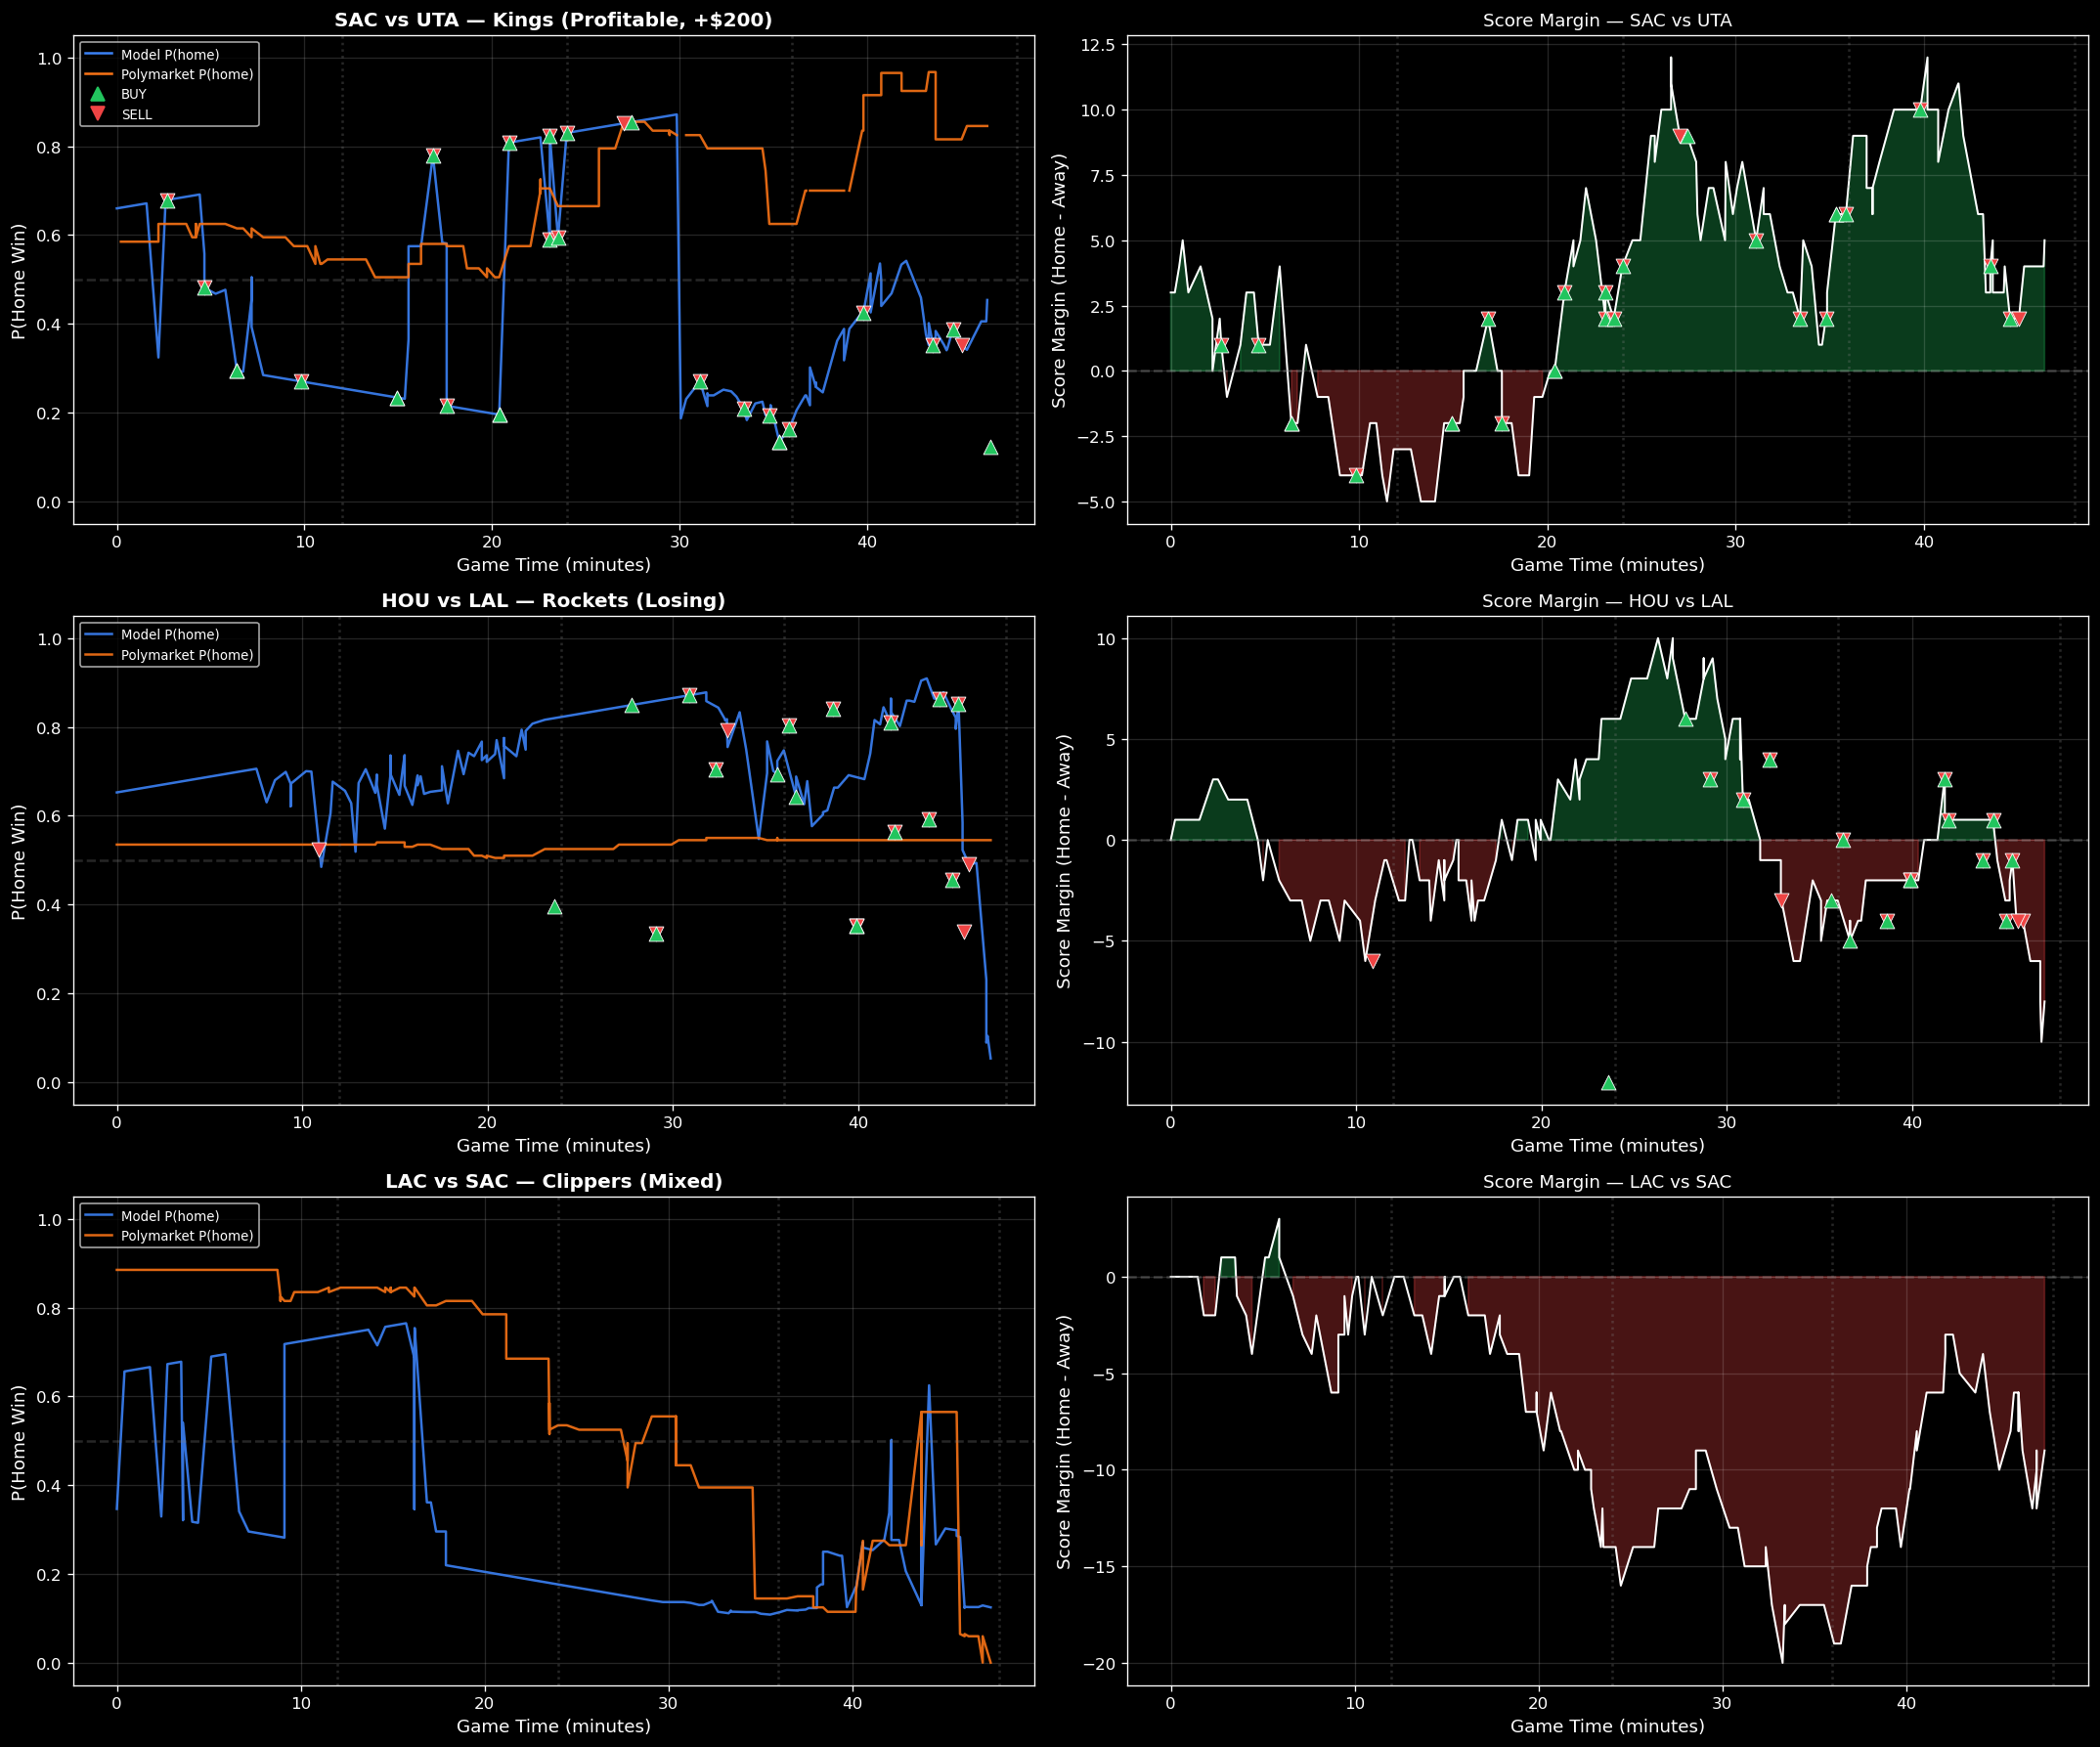

  SAC vs UTA — Kings (Profitable, +$200)
    Trades: 46 total, 18 resolved, PnL: $200.26

  HOU vs LAL — Rockets (Losing)
    Trades: 34 total, 17 resolved, PnL: $-59.57

  LAC vs SAC — Clippers (Mixed)
    Trades: 28 total, 11 resolved, PnL: $36.30



In [27]:
# ── Section 3: Live Snapshot Time Series ─────────────────────────────────────
# Game mappings: snapshots use NBA game_id, trades use polymarket hex hash
# We match by team names in the target_team column

game_configs = [
    {
        "snap_id": "0022500982",
        "trade_id": "0x81672be3a86cb59edbdf292fa223d2a74703eb4e3f0bf570587bcae830928822",
        "label": "SAC vs UTA — Kings (Profitable, +$200)",
        "color": GREEN,
    },
    {
        "snap_id": "0022500989",
        "trade_ids": [
            "0xe2585a9e1c2e700b6e1d8f63b04602df9426a685c87185bfef5ea63d758ab900",
            "0xde957071fc8376b6c7e9a2b1701fa43ddd1c846a313eabc73b351106a19072c7",
        ],
        "label": "HOU vs LAL — Rockets (Losing)",
        "color": RED,
    },
    {
        "snap_id": "0022500975",
        "trade_id": "0x671b141d1a220a996d5c7074e155edb1b3c82d61ecdee605ebe5fbe7e540d89a",
        "label": "LAC vs SAC — Clippers (Mixed)",
        "color": BLUE,
    },
]

fig, axes = plt.subplots(len(game_configs), 2, figsize=(18, 5 * len(game_configs)),
                         gridspec_kw={"width_ratios": [3, 3]})

for i, gcfg in enumerate(game_configs):
    # Get snapshots for this game
    gsnap = snapshots[snapshots["game_id"] == gcfg["snap_id"]].copy()
    gsnap = gsnap.sort_values("game_seconds_left", ascending=False)

    # Game time elapsed = total_time - secs_left (so x goes left=start, right=end)
    total_secs = gsnap["game_seconds_left"].max()
    gsnap["elapsed"] = total_secs - gsnap["game_seconds_left"]
    gsnap["elapsed_min"] = gsnap["elapsed"] / 60.0

    # Get trades for this game
    if "trade_ids" in gcfg:
        gtrades = trades_all[trades_all["game_id"].isin(gcfg["trade_ids"])].copy()
    else:
        gtrades = trades_all[trades_all["game_id"] == gcfg["trade_id"]].copy()

    # Map trade secs_left to elapsed time
    if "secs_left" in gtrades.columns and gtrades["secs_left"].notna().any():
        gtrades["elapsed_min"] = (total_secs - gtrades["secs_left"].fillna(0)) / 60.0
    else:
        gtrades["elapsed_min"] = np.nan

    # ─── Top subplot: probabilities ───
    ax_prob = axes[i, 0]
    ax_prob.plot(gsnap["elapsed_min"], gsnap["model_win_prob"],
                 color=BLUE, linewidth=1.5, label="Model P(home)", alpha=0.9)
    ax_prob.plot(gsnap["elapsed_min"], gsnap["polymarket_home_prob"],
                 color=ORANGE, linewidth=1.5, label="Polymarket P(home)", alpha=0.9)
    ax_prob.axhline(0.5, color="gray", linestyle="--", alpha=0.3)

    # Overlay trade points
    for _, tr in gtrades.iterrows():
        if pd.notna(tr.get("elapsed_min")):
            is_buy = "BUY" in str(tr.get("action", ""))
            marker = "^" if is_buy else "v"
            color = GREEN if is_buy else RED
            y_val = tr.get("model_implied_prob", 0.5)
            ax_prob.scatter(tr["elapsed_min"], y_val, marker=marker, color=color,
                           s=80, zorder=10, edgecolors="white", linewidth=0.5)

    ax_prob.set_ylabel("P(Home Win)")
    ax_prob.set_title(gcfg["label"], fontsize=12, fontweight="bold")
    ax_prob.legend(loc="upper left", fontsize=8)
    ax_prob.set_ylim(-0.05, 1.05)
    ax_prob.grid(alpha=0.15)

    # Add quarter boundaries
    for q_end in [12, 24, 36, 48]:
        ax_prob.axvline(q_end, color="gray", linestyle=":", alpha=0.3)

    # ─── Bottom subplot: score margin ───
    ax_margin = axes[i, 1]
    gsnap["margin"] = gsnap["home_score"] - gsnap["away_score"]
    ax_margin.fill_between(gsnap["elapsed_min"], 0, gsnap["margin"],
                           where=gsnap["margin"] >= 0, color=GREEN, alpha=0.3)
    ax_margin.fill_between(gsnap["elapsed_min"], 0, gsnap["margin"],
                           where=gsnap["margin"] < 0, color=RED, alpha=0.3)
    ax_margin.plot(gsnap["elapsed_min"], gsnap["margin"], color="white", linewidth=1.2)
    ax_margin.axhline(0, color="gray", linestyle="--", alpha=0.4)

    # Trade markers on margin chart too
    for _, tr in gtrades.iterrows():
        if pd.notna(tr.get("elapsed_min")) and pd.notna(tr.get("home_score")) and pd.notna(tr.get("away_score")):
            is_buy = "BUY" in str(tr.get("action", ""))
            marker = "^" if is_buy else "v"
            color = GREEN if is_buy else RED
            margin_val = tr["home_score"] - tr["away_score"]
            ax_margin.scatter(tr["elapsed_min"], margin_val, marker=marker, color=color,
                             s=80, zorder=10, edgecolors="white", linewidth=0.5)

    ax_margin.set_ylabel("Score Margin (Home - Away)")
    ax_margin.set_xlabel("Game Time (minutes)")
    ax_margin.set_title(f"Score Margin — {gcfg['label'].split('—')[0].strip()}", fontsize=11)
    ax_margin.grid(alpha=0.15)
    for q_end in [12, 24, 36, 48]:
        ax_margin.axvline(q_end, color="gray", linestyle=":", alpha=0.3)

    ax_prob.set_xlabel("Game Time (minutes)")

# Custom legend for trade markers
buy_marker = Line2D([], [], marker="^", color=GREEN, linestyle="None", markersize=8, label="BUY")
sell_marker = Line2D([], [], marker="v", color=RED, linestyle="None", markersize=8, label="SELL")
axes[0, 0].legend(handles=[
    Line2D([], [], color=BLUE, label="Model P(home)"),
    Line2D([], [], color=ORANGE, label="Polymarket P(home)"),
    buy_marker, sell_marker,
], loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

# Print summary for each game
for gcfg in game_configs:
    if "trade_ids" in gcfg:
        gt = trades_all[trades_all["game_id"].isin(gcfg["trade_ids"])]
    else:
        gt = trades_all[trades_all["game_id"] == gcfg.get("trade_id", "")]
    resolved = gt[gt["pnl"].notna() & (gt["pnl"] != 0)]
    total_pnl = resolved["pnl"].sum()
    print(f"  {gcfg['label']}")
    print(f"    Trades: {len(gt)} total, {len(resolved)} resolved, PnL: ${total_pnl:.2f}")
    print()

---
## Section 4: Buy/Sell Sequencing & Round-Trip Analysis

Analyze trading patterns per game: buy/sell counts, round-trip sequences (buy-sell-buy cycles), and whether more frequent trading correlates with better or worse PnL.

In [28]:
# ── Section 4: Buy/Sell Sequencing & Round-Trip Analysis ─────────────────────
trades_seq = trades_all.copy()
trades_seq["timestamp"] = pd.to_datetime(trades_seq["timestamp"])
trades_seq["is_buy"] = trades_seq["action"].str.contains("BUY", na=False)

# Per-game stats
game_stats = []
for gid, grp in trades_seq.groupby("game_id"):
    grp_sorted = grp.sort_values("timestamp")
    n_total = len(grp_sorted)
    n_buy = grp_sorted["is_buy"].sum()
    n_sell = n_total - n_buy
    resolved = grp_sorted[(grp_sorted["pnl"].notna()) & (grp_sorted["pnl"] != 0)]
    total_pnl = resolved["pnl"].sum()

    # Count round trips: buy-sell-buy sequences
    actions = grp_sorted["is_buy"].values
    round_trips = 0
    for j in range(2, len(actions)):
        if actions[j-2] and not actions[j-1] and actions[j]:
            round_trips += 1

    game_stats.append({
        "game_id": gid,
        "target_team": grp_sorted["target_team"].iloc[0],
        "total_trades": n_total,
        "buys": int(n_buy),
        "sells": int(n_sell),
        "round_trips": round_trips,
        "pnl": total_pnl,
    })

gs = pd.DataFrame(game_stats).sort_values("total_trades", ascending=False)

print("  BUY/SELL SEQUENCING SUMMARY")
print("  " + "=" * 80)
print(f"  Total unique games traded:  {len(gs)}")
print(f"  Avg trades per game:        {gs['total_trades'].mean():.1f}")
print(f"  Games with >5 trades:       {(gs['total_trades'] > 5).sum()}")
print(f"  Games with >10 trades:      {(gs['total_trades'] > 10).sum()}")
print(f"  Total round-trips:          {gs['round_trips'].sum()}")
print(f"  Games with round-trips:     {(gs['round_trips'] > 0).sum()}")
print()

# Correlation between trade count and PnL
corr_trades_pnl = gs[["total_trades", "pnl"]].corr().iloc[0, 1]
corr_rt_pnl = gs[["round_trips", "pnl"]].corr().iloc[0, 1]
print(f"  Correlation (trade count vs PnL): {corr_trades_pnl:+.3f}")
print(f"  Correlation (round-trips vs PnL): {corr_rt_pnl:+.3f}")
print()

# Top games table
print(f"  {'Game':<40} {'Trades':>7} {'Buys':>5} {'Sells':>6} {'RTs':>4} {'PnL':>10}")
print("  " + "-" * 80)
for _, row in gs.head(15).iterrows():
    label = f"{row['game_id'][:10]}... {row['target_team']}"
    print(f"  {label:<40} {row['total_trades']:>7} {row['buys']:>5} {row['sells']:>6} {row['round_trips']:>4} ${row['pnl']:>9.2f}")
print("  " + "=" * 80)

  BUY/SELL SEQUENCING SUMMARY
  Total unique games traded:  45
  Avg trades per game:        11.4
  Games with >5 trades:       20
  Games with >10 trades:      18
  Total round-trips:          204
  Games with round-trips:     32

  Correlation (trade count vs PnL): +0.530
  Correlation (round-trips vs PnL): +0.527

  Game                                      Trades  Buys  Sells  RTs        PnL
  --------------------------------------------------------------------------------
  0x40e9eade... Trail Blazers vs. 76ers         62    35     27   26 $    -6.57
  0x81672be3... Jazz vs. Kings                  46    27     19   18 $   200.26
  0x21a3b5f6... Bucks vs. Suns                  38    19     19   18 $   219.55
  0xc4eea371... Warriors vs. Knicks             37    24     13   12 $    63.84
  0x671b141d... Kings vs. Clippers              28    17     11   10 $    36.30
  0xe5b34d47... Suns vs. Celtics                28    14     14   13 $     6.95
  0xeee40ed2... Suns vs. Timberwolves 

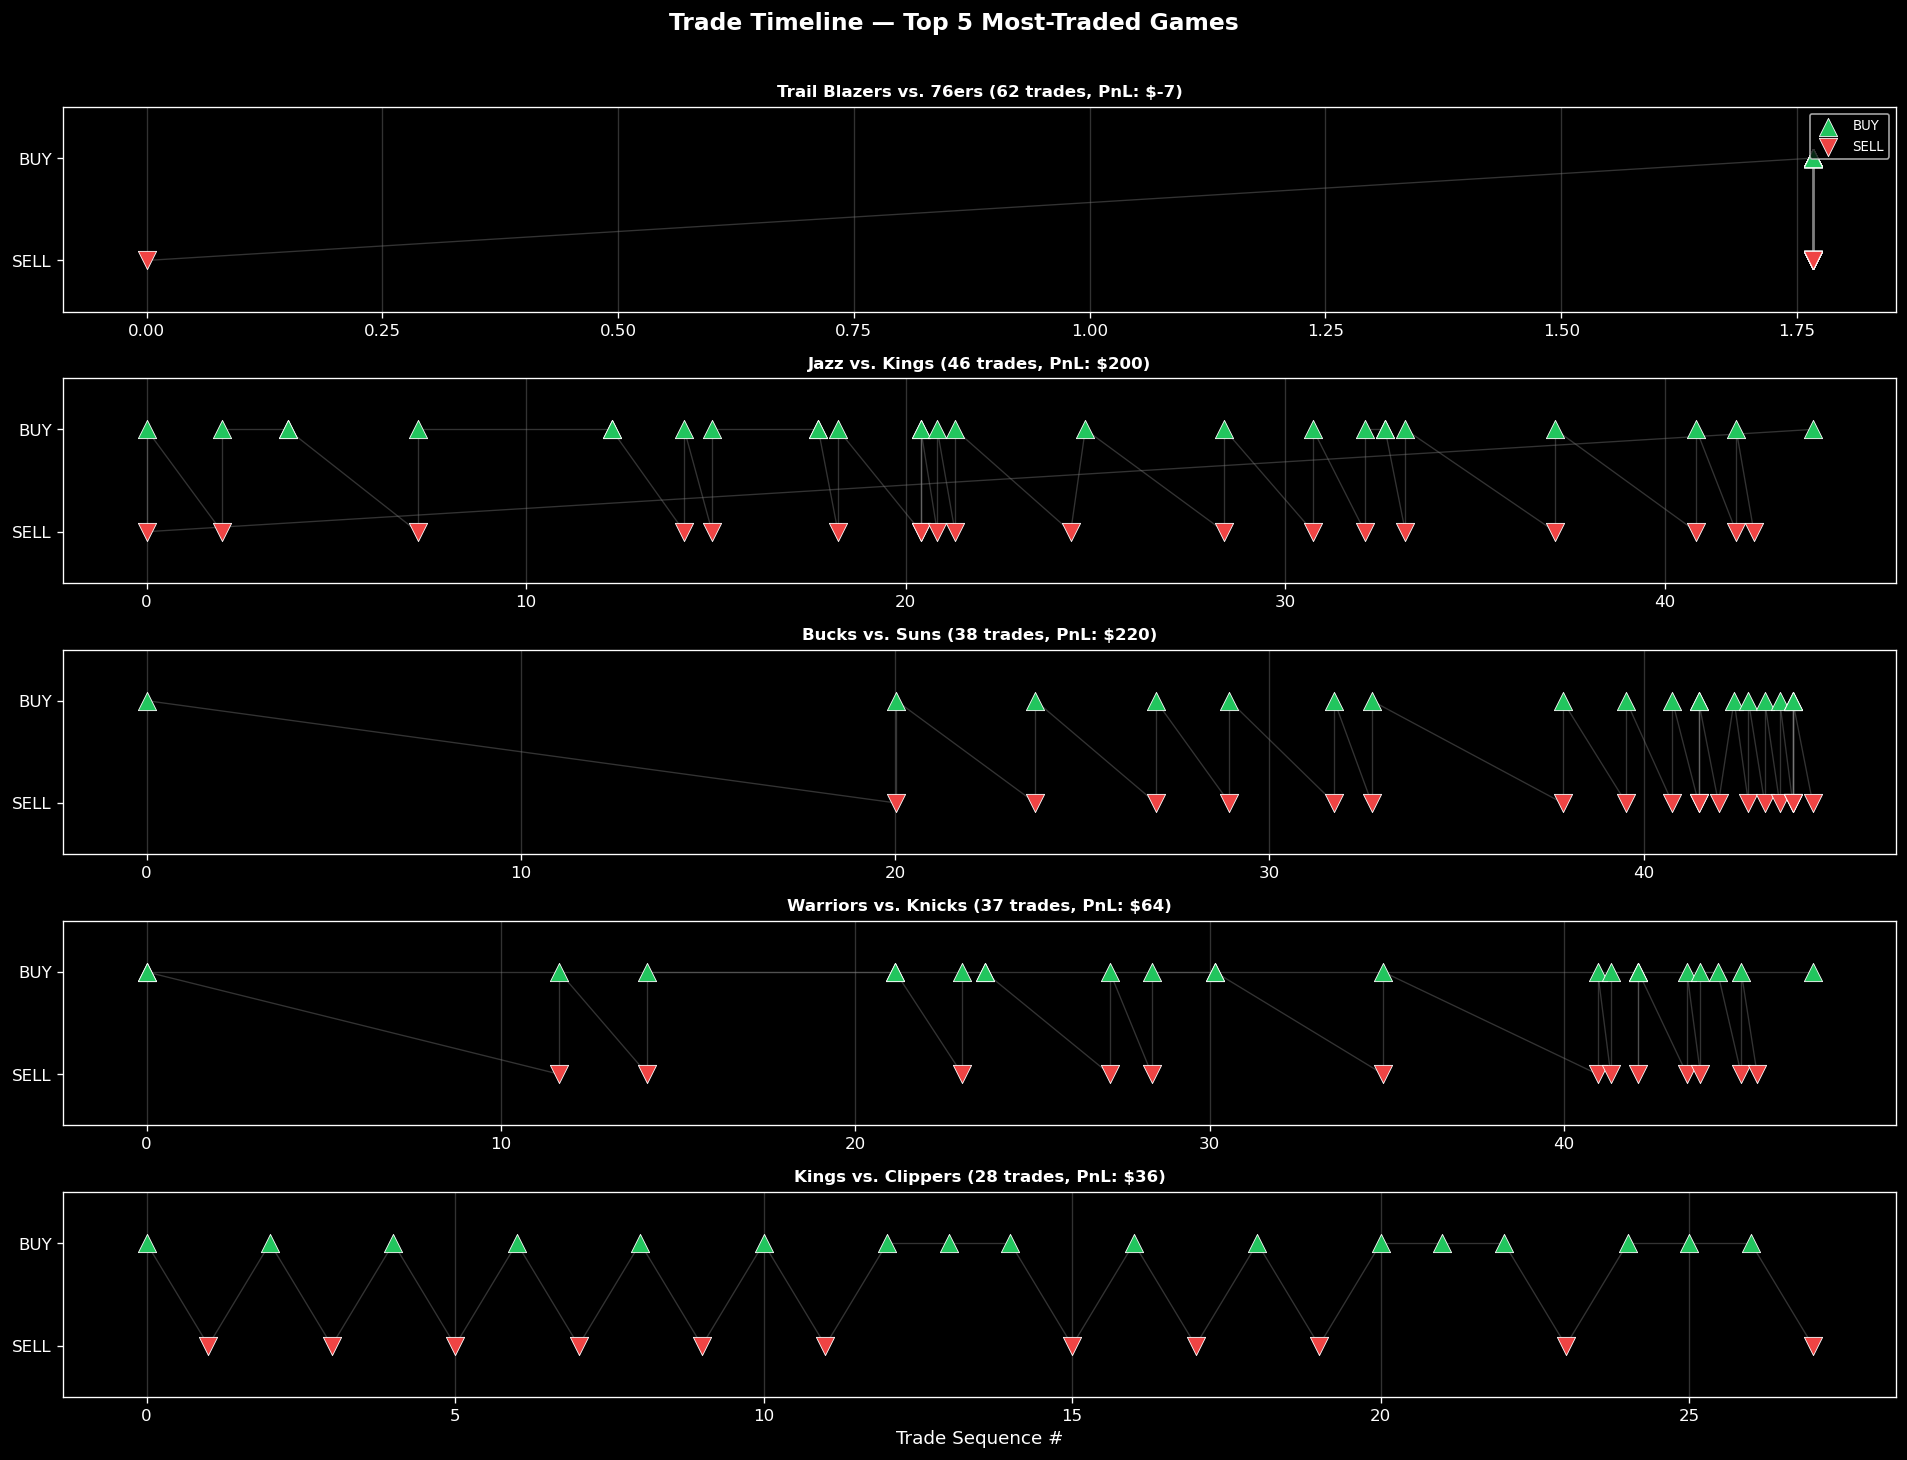


  ROUND-TRIP vs PnL ANALYSIS
  Games WITH round-trips:   32, avg PnL: $    9.76
  Games WITHOUT round-trips:  13, avg PnL: $   -2.69


In [29]:
# ── Timeline visualization for top 5 most-traded games ───────────────────────
top5 = gs.head(5)

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=False)

for idx, (_, row) in enumerate(top5.iterrows()):
    ax = axes[idx]
    gid = row["game_id"]
    grp = trades_seq[trades_seq["game_id"] == gid].sort_values("timestamp").copy()

    if grp["secs_left"].notna().any():
        total_secs = grp["secs_left"].max()
        grp["elapsed_min"] = (total_secs - grp["secs_left"].fillna(0)) / 60.0
        x_vals = grp["elapsed_min"]
        x_label = "Game Time (minutes)"
    else:
        # Fallback to timestamp ordering
        grp["trade_idx"] = range(len(grp))
        x_vals = grp["trade_idx"]
        x_label = "Trade Sequence #"

    buys = grp[grp["is_buy"]]
    sells = grp[~grp["is_buy"]]

    ax.scatter(x_vals[grp["is_buy"]], [1] * len(buys), marker="^", color=GREEN,
               s=120, zorder=5, edgecolors="white", linewidth=0.5, label="BUY")
    ax.scatter(x_vals[~grp["is_buy"]], [0] * len(sells), marker="v", color=RED,
               s=120, zorder=5, edgecolors="white", linewidth=0.5, label="SELL")

    # Connect trades with lines
    for j in range(1, len(grp)):
        xv = x_vals.values
        yv = grp["is_buy"].astype(int).values
        ax.plot([xv[j-1], xv[j]], [yv[j-1], yv[j]], color="gray", alpha=0.4, linewidth=0.8)

    label = f"{row['target_team']} ({row['total_trades']} trades, PnL: ${row['pnl']:.0f})"
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["SELL", "BUY"])
    ax.set_ylim(-0.5, 1.5)
    ax.grid(axis="x", alpha=0.2)
    if idx == 4:
        ax.set_xlabel(x_label)

axes[0].legend(loc="upper right", fontsize=8)
plt.suptitle("Trade Timeline — Top 5 Most-Traded Games", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Round-trip PnL analysis
print("\n  ROUND-TRIP vs PnL ANALYSIS")
print("  " + "=" * 50)
has_rt = gs[gs["round_trips"] > 0]
no_rt = gs[gs["round_trips"] == 0]
print(f"  Games WITH round-trips:  {len(has_rt):>3}, avg PnL: ${has_rt['pnl'].mean():>8.2f}")
print(f"  Games WITHOUT round-trips: {len(no_rt):>3}, avg PnL: ${no_rt['pnl'].mean():>8.2f}")
print("  " + "=" * 50)

---
## Section 5: Score Differential & Time Remaining at Trade

Analyze when trades fire relative to the game clock and score state. Do winning trades tend to happen at different margins or time points than losing trades?

In [30]:
# ── Section 5: Score Differential & Time Remaining ───────────────────────────
trades_score = trades[trades["home_score"].notna()].copy()
trades_score["raw_margin"] = trades_score["home_score"] - trades_score["away_score"]

# Margin from bet-side perspective: if bought_home=0 (away bet), flip sign
trades_score["bet_margin"] = np.where(
    trades_score["bought_home"] == 1,
    trades_score["raw_margin"],
    -trades_score["raw_margin"],
)
trades_score["minutes_left"] = trades_score["secs_left"] / 60.0

# Determine quarter from secs_left (assuming 48-min game: Q1=2880-2161, Q2=2160-1441, Q3=1440-721, Q4=720-0)
def get_quarter(secs):
    if pd.isna(secs):
        return None
    if secs > 2160:
        return 1
    elif secs > 1440:
        return 2
    elif secs > 720:
        return 3
    else:
        return 4

trades_score["quarter"] = trades_score["secs_left"].apply(get_quarter)

print(f"  Trades with score data: {len(trades_score)}")
print(f"  Wins: {trades_score['won'].sum()}, Losses: {(trades_score['won'] == 0).sum()}")
print()

# Stats
wins = trades_score[trades_score["won"] == 1]
losses = trades_score[trades_score["won"] == 0]

print("  MARGIN AT ENTRY (from bet-side perspective)")
print("  " + "-" * 50)
print(f"  Wins  — avg margin: {wins['bet_margin'].mean():+.1f}, median: {wins['bet_margin'].median():+.1f}")
print(f"  Losses — avg margin: {losses['bet_margin'].mean():+.1f}, median: {losses['bet_margin'].median():+.1f}")
print()
print("  TIME REMAINING AT ENTRY")
print("  " + "-" * 50)
print(f"  Wins  — avg mins left: {wins['minutes_left'].mean():.1f}, median: {wins['minutes_left'].median():.1f}")
print(f"  Losses — avg mins left: {losses['minutes_left'].mean():.1f}, median: {losses['minutes_left'].median():.1f}")
print()

# Quarter distribution
q_dist = trades_score.groupby("quarter").agg(
    count=("won", "size"),
    wins=("won", "sum"),
    pnl=("pnl", "sum"),
).reset_index()
q_dist["pct"] = q_dist["count"] / q_dist["count"].sum() * 100
q_dist["win_rate"] = q_dist["wins"] / q_dist["count"] * 100

print("  TRADES BY QUARTER")
print("  " + "-" * 60)
print(f"  {'Q':>3} {'Count':>7} {'%':>7} {'Wins':>6} {'Win%':>7} {'PnL':>10}")
for _, row in q_dist.iterrows():
    print(f"  Q{int(row['quarter']):>2} {int(row['count']):>7} {row['pct']:>6.1f}% {int(row['wins']):>6} {row['win_rate']:>6.1f}% ${row['pnl']:>9.2f}")
print("  " + "-" * 60)

  Trades with score data: 182
  Wins: 94, Losses: 88

  MARGIN AT ENTRY (from bet-side perspective)
  --------------------------------------------------
  Wins  — avg margin: +2.1, median: +2.0
  Losses — avg margin: -3.0, median: -2.0

  TIME REMAINING AT ENTRY
  --------------------------------------------------
  Wins  — avg mins left: 13.7, median: 13.2
  Losses — avg mins left: 14.3, median: 10.7

  TRADES BY QUARTER
  ------------------------------------------------------------
    Q   Count       %   Wins    Win%        PnL
  Q 1      11    6.0%      5   45.5% $   -33.18
  Q 2      18    9.9%      8   44.4% $   151.87
  Q 3      59   32.4%     36   61.0% $   152.27
  Q 4      94   51.6%     45   47.9% $   -15.20
  ------------------------------------------------------------


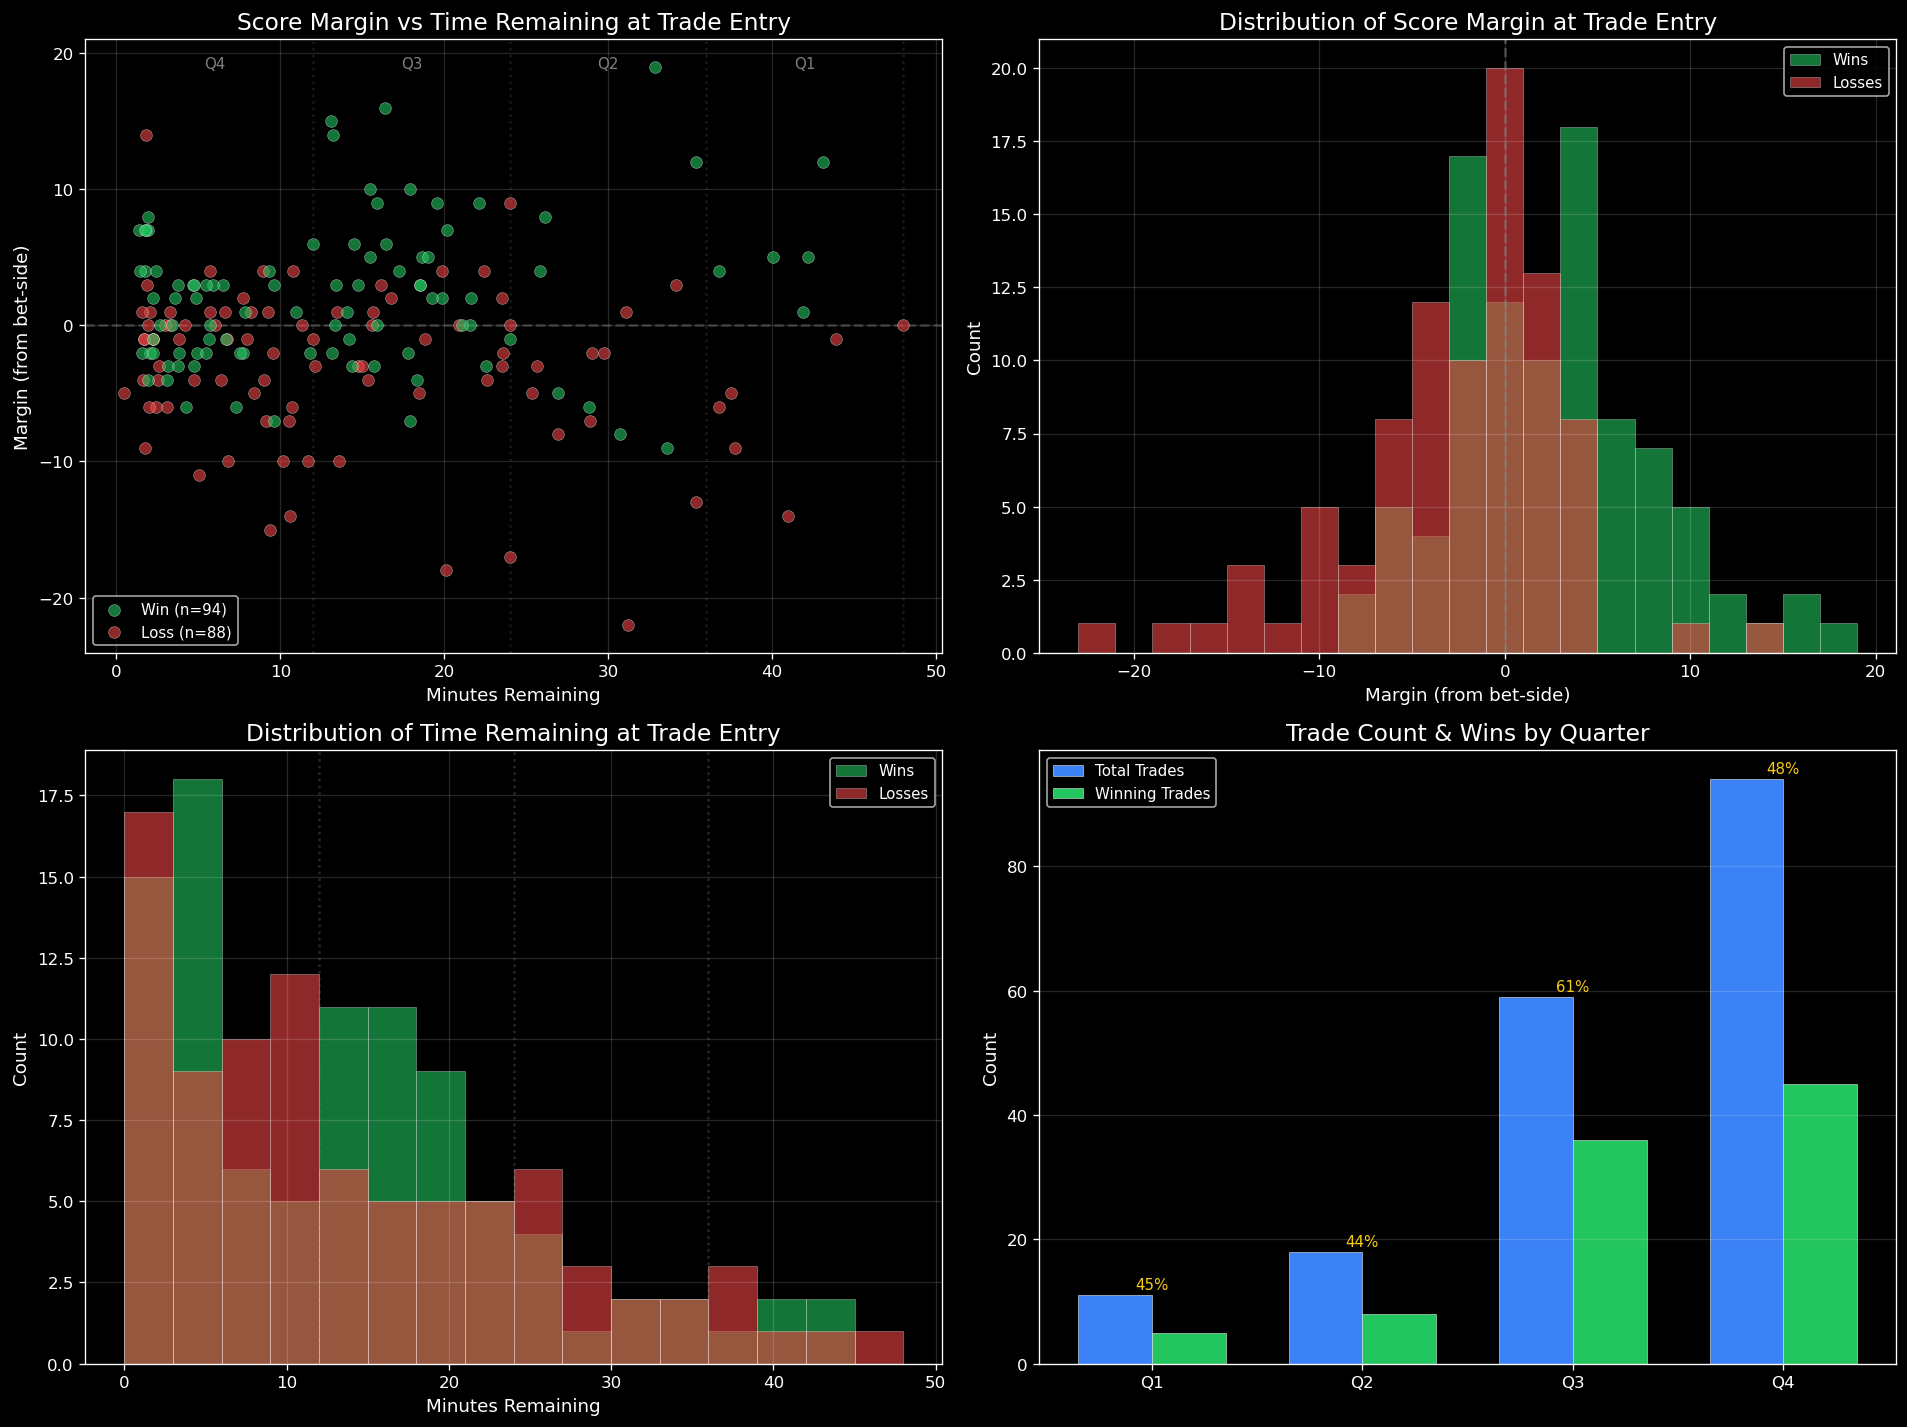

In [31]:
# ── Section 5: Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ─── 2D Scatter: time remaining vs margin, colored by outcome ───
ax = axes[0, 0]
w = trades_score[trades_score["won"] == 1]
l = trades_score[trades_score["won"] == 0]
ax.scatter(w["minutes_left"], w["bet_margin"], color=GREEN, alpha=0.6, s=50,
           edgecolors="white", linewidth=0.3, label=f"Win (n={len(w)})", zorder=5)
ax.scatter(l["minutes_left"], l["bet_margin"], color=RED, alpha=0.6, s=50,
           edgecolors="white", linewidth=0.3, label=f"Loss (n={len(l)})", zorder=4)
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Minutes Remaining")
ax.set_ylabel("Margin (from bet-side)")
ax.set_title("Score Margin vs Time Remaining at Trade Entry")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)
# Add quarter labels
for q, x_pos in [(1, 42), (2, 30), (3, 18), (4, 6)]:
    ax.axvline(q * 12, color="gray", linestyle=":", alpha=0.2)
    ax.text(x_pos, ax.get_ylim()[1] * 0.9, f"Q{q}", color="gray", fontsize=9, ha="center")

# ─── Histogram: margin at trade ───
ax = axes[0, 1]
bins_margin = np.arange(trades_score["bet_margin"].min() - 1, trades_score["bet_margin"].max() + 2, 2)
ax.hist(w["bet_margin"], bins=bins_margin, color=GREEN, alpha=0.6, label="Wins", edgecolor="white", linewidth=0.3)
ax.hist(l["bet_margin"], bins=bins_margin, color=RED, alpha=0.6, label="Losses", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Margin (from bet-side)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Score Margin at Trade Entry")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)

# ─── Histogram: time remaining ───
ax = axes[1, 0]
bins_time = np.arange(0, trades_score["minutes_left"].max() + 2, 3)
ax.hist(w["minutes_left"], bins=bins_time, color=GREEN, alpha=0.6, label="Wins", edgecolor="white", linewidth=0.3)
ax.hist(l["minutes_left"], bins=bins_time, color=RED, alpha=0.6, label="Losses", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Minutes Remaining")
ax.set_ylabel("Count")
ax.set_title("Distribution of Time Remaining at Trade Entry")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)
for q in [12, 24, 36]:
    ax.axvline(q, color="gray", linestyle=":", alpha=0.3)

# ─── Bar chart: trades by quarter ───
ax = axes[1, 1]
quarters = q_dist["quarter"].astype(int)
bar_width = 0.35
x_pos = np.arange(len(quarters))
ax.bar(x_pos - bar_width/2, q_dist["count"], bar_width, color=BLUE, label="Total Trades", edgecolor="white", linewidth=0.3)
ax.bar(x_pos + bar_width/2, q_dist["wins"], bar_width, color=GREEN, label="Winning Trades", edgecolor="white", linewidth=0.3)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Q{int(q)}" for q in quarters])
ax.set_ylabel("Count")
ax.set_title("Trade Count & Wins by Quarter")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.15)

# Add win rate annotation
for idx_q, (_, row) in enumerate(q_dist.iterrows()):
    ax.text(idx_q, row["count"] + 1, f"{row['win_rate']:.0f}%", ha="center", fontsize=9, color=YELLOW)

plt.tight_layout()
plt.show()

---
## Section 6: Bid-Ask Spread Analysis

Examine Polymarket bid-ask spreads from snapshot data and volume distribution as a proxy for liquidity conditions the bot traded in.

  Snapshots with bid data: 10748 / 12081
  Snapshots with ask data: 10748 / 12081

  BID-ASK SPREAD STATISTICS
  Snapshots with spread data: 10748
  Mean spread:                -0.0000
  Median spread:              0.0000
  Std spread:                 0.0000
  Max spread:                 0.0000
  Mean spread (% of mid):     -0.00%

  NOTE: 6225/10748 snapshots have bid == ask (locked/no real spread)
  This suggests bid-ask data may not reflect true order book spreads.
  Estimating implementation shortfall from model vs market gap instead.

  MODEL vs MARKET GAP (Implementation Shortfall Proxy)
  Mean |model - market|: 0.2226
  Median:                0.1562
  Max:                   0.7202

  POLYMARKET VOLUME (max per game)
  Games with volume data: 59
  Mean volume:   $2,296,731
  Median volume: $2,102,512
  Max volume:    $5,705,815
  Min volume:    $45,708


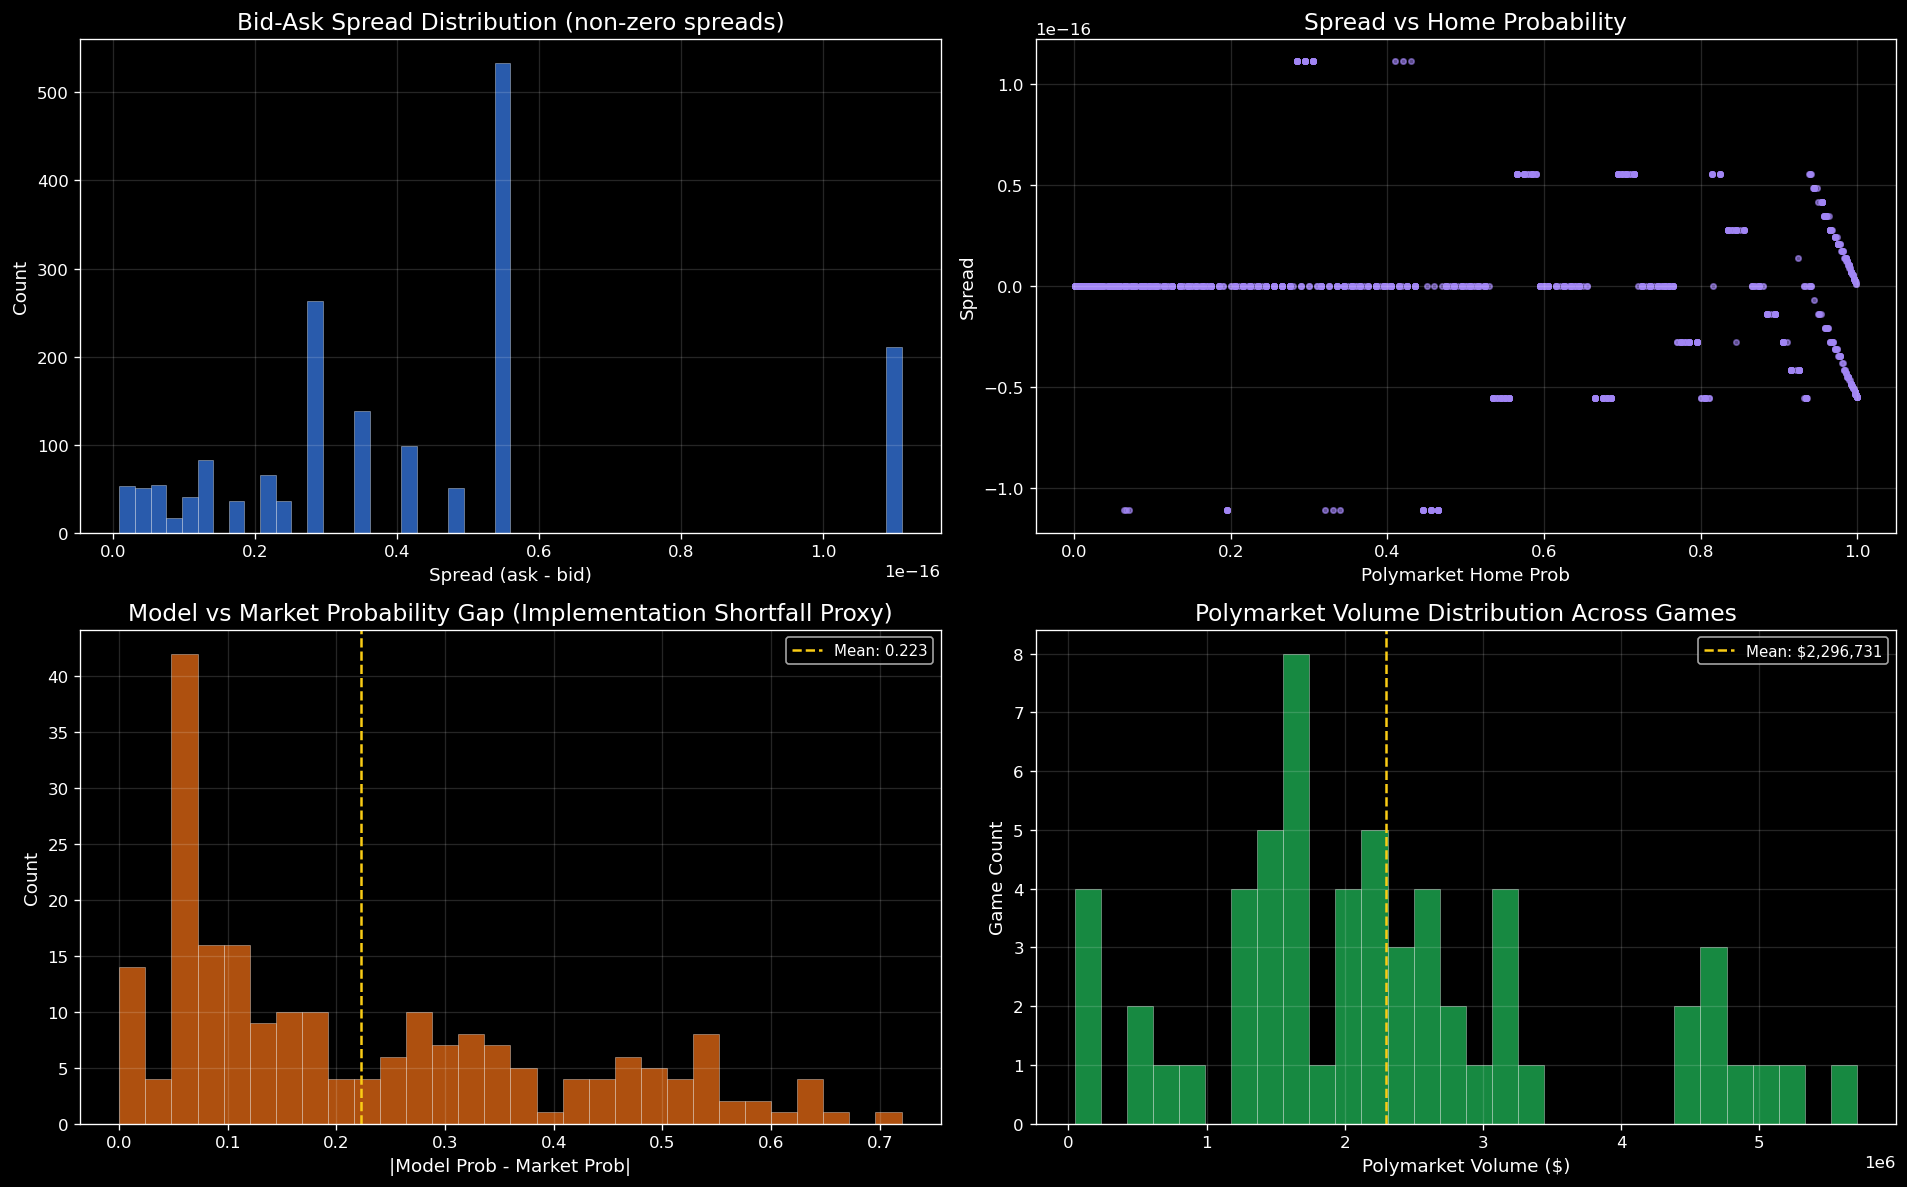

In [32]:
# ── Section 6: Bid-Ask Spread Analysis ───────────────────────────────────────
has_bid_ask = snapshots["polymarket_bid"].notna().sum()
has_ask = snapshots["polymarket_ask"].notna().sum()

print(f"  Snapshots with bid data: {has_bid_ask} / {len(snapshots)}")
print(f"  Snapshots with ask data: {has_ask} / {len(snapshots)}")
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if has_bid_ask > 100:
    # Compute spread where both bid and ask are available
    spread_df = snapshots[snapshots["polymarket_bid"].notna() & snapshots["polymarket_ask"].notna()].copy()
    spread_df["spread"] = spread_df["polymarket_ask"] - spread_df["polymarket_bid"]
    spread_df["mid"] = (spread_df["polymarket_bid"] + spread_df["polymarket_ask"]) / 2.0
    spread_df["spread_pct"] = spread_df["spread"] / spread_df["mid"] * 100

    print("  BID-ASK SPREAD STATISTICS")
    print("  " + "=" * 50)
    print(f"  Snapshots with spread data: {len(spread_df)}")
    print(f"  Mean spread:                {spread_df['spread'].mean():.4f}")
    print(f"  Median spread:              {spread_df['spread'].median():.4f}")
    print(f"  Std spread:                 {spread_df['spread'].std():.4f}")
    print(f"  Max spread:                 {spread_df['spread'].max():.4f}")
    print(f"  Mean spread (% of mid):     {spread_df['spread_pct'].mean():.2f}%")
    print()

    # Check for bid == ask (locked markets / no real spread data)
    locked = (spread_df["spread"] == 0).sum()
    if locked > len(spread_df) * 0.5:
        print(f"  NOTE: {locked}/{len(spread_df)} snapshots have bid == ask (locked/no real spread)")
        print("  This suggests bid-ask data may not reflect true order book spreads.")
        print("  Estimating implementation shortfall from model vs market gap instead.\n")

    # Plot spread distribution
    ax = axes[0, 0]
    valid_spreads = spread_df[spread_df["spread"] > 0]["spread"]
    if len(valid_spreads) > 10:
        ax.hist(valid_spreads, bins=50, color=BLUE, alpha=0.7, edgecolor="white", linewidth=0.3)
        ax.set_title("Bid-Ask Spread Distribution (non-zero spreads)")
    else:
        ax.hist(spread_df["spread"], bins=50, color=BLUE, alpha=0.7, edgecolor="white", linewidth=0.3)
        ax.set_title("Bid-Ask Spread Distribution")
    ax.set_xlabel("Spread (ask - bid)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.15)

    # Spread over time
    ax = axes[0, 1]
    ax.scatter(spread_df["polymarket_home_prob"], spread_df["spread"],
               alpha=0.15, s=10, color=PURPLE)
    ax.set_xlabel("Polymarket Home Prob")
    ax.set_ylabel("Spread")
    ax.set_title("Spread vs Home Probability")
    ax.grid(alpha=0.15)

else:
    print("  Bid-ask data is sparse or unavailable.")
    print("  Estimating implementation shortfall from model vs market probability gap.\n")

    axes[0, 0].text(0.5, 0.5, "Bid-ask data not available\n(see implementation shortfall below)",
                     ha="center", va="center", fontsize=12, color="gray",
                     transform=axes[0, 0].transAxes)
    axes[0, 0].set_title("Bid-Ask Spread (N/A)")

    axes[0, 1].text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=14, color="gray",
                     transform=axes[0, 1].transAxes)
    axes[0, 1].set_title("Spread vs Prob (N/A)")

# ─── Implementation shortfall: model_implied_prob vs market_implied_prob gap ───
trades_gap = trades.copy()
trades_gap["prob_gap"] = abs(trades_gap["model_implied_prob"] - trades_gap["market_implied_prob"])

ax = axes[1, 0]
ax.hist(trades_gap["prob_gap"], bins=30, color=ORANGE, alpha=0.7, edgecolor="white", linewidth=0.3)
ax.axvline(trades_gap["prob_gap"].mean(), color=YELLOW, linestyle="--", linewidth=1.5,
           label=f"Mean: {trades_gap['prob_gap'].mean():.3f}")
ax.set_xlabel("|Model Prob - Market Prob|")
ax.set_ylabel("Count")
ax.set_title("Model vs Market Probability Gap (Implementation Shortfall Proxy)")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)

print("  MODEL vs MARKET GAP (Implementation Shortfall Proxy)")
print("  " + "=" * 50)
print(f"  Mean |model - market|: {trades_gap['prob_gap'].mean():.4f}")
print(f"  Median:                {trades_gap['prob_gap'].median():.4f}")
print(f"  Max:                   {trades_gap['prob_gap'].max():.4f}")
print()

# ─── Polymarket volume distribution ───
ax = axes[1, 1]
vol_data = snapshots[snapshots["polymarket_volume"].notna()]["polymarket_volume"]

if len(vol_data) > 0:
    # Volume per game
    vol_per_game = snapshots.groupby("game_id")["polymarket_volume"].max()
    ax.hist(vol_per_game.dropna(), bins=30, color=GREEN, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.axvline(vol_per_game.mean(), color=YELLOW, linestyle="--", linewidth=1.5,
               label=f"Mean: ${vol_per_game.mean():,.0f}")
    ax.set_xlabel("Polymarket Volume ($)")
    ax.set_ylabel("Game Count")
    ax.set_title("Polymarket Volume Distribution Across Games")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.15)

    print("  POLYMARKET VOLUME (max per game)")
    print("  " + "=" * 50)
    print(f"  Games with volume data: {vol_per_game.notna().sum()}")
    print(f"  Mean volume:   ${vol_per_game.mean():,.0f}")
    print(f"  Median volume: ${vol_per_game.median():,.0f}")
    print(f"  Max volume:    ${vol_per_game.max():,.0f}")
    print(f"  Min volume:    ${vol_per_game.min():,.0f}")
else:
    ax.text(0.5, 0.5, "Volume data not available", ha="center", va="center",
            fontsize=12, color="gray", transform=ax.transAxes)
    ax.set_title("Volume Distribution (N/A)")
    print("  Polymarket volume data not available in snapshots.")

plt.tight_layout()
plt.show()

---
## Section 7: Sub-Model Output Decomposition

Analyze the relationship and volatility of the 5 sub-model outputs (model_win_prob, model_proxy_prob, model_margin, model_edge, model_edge_confidence) across games and over time.

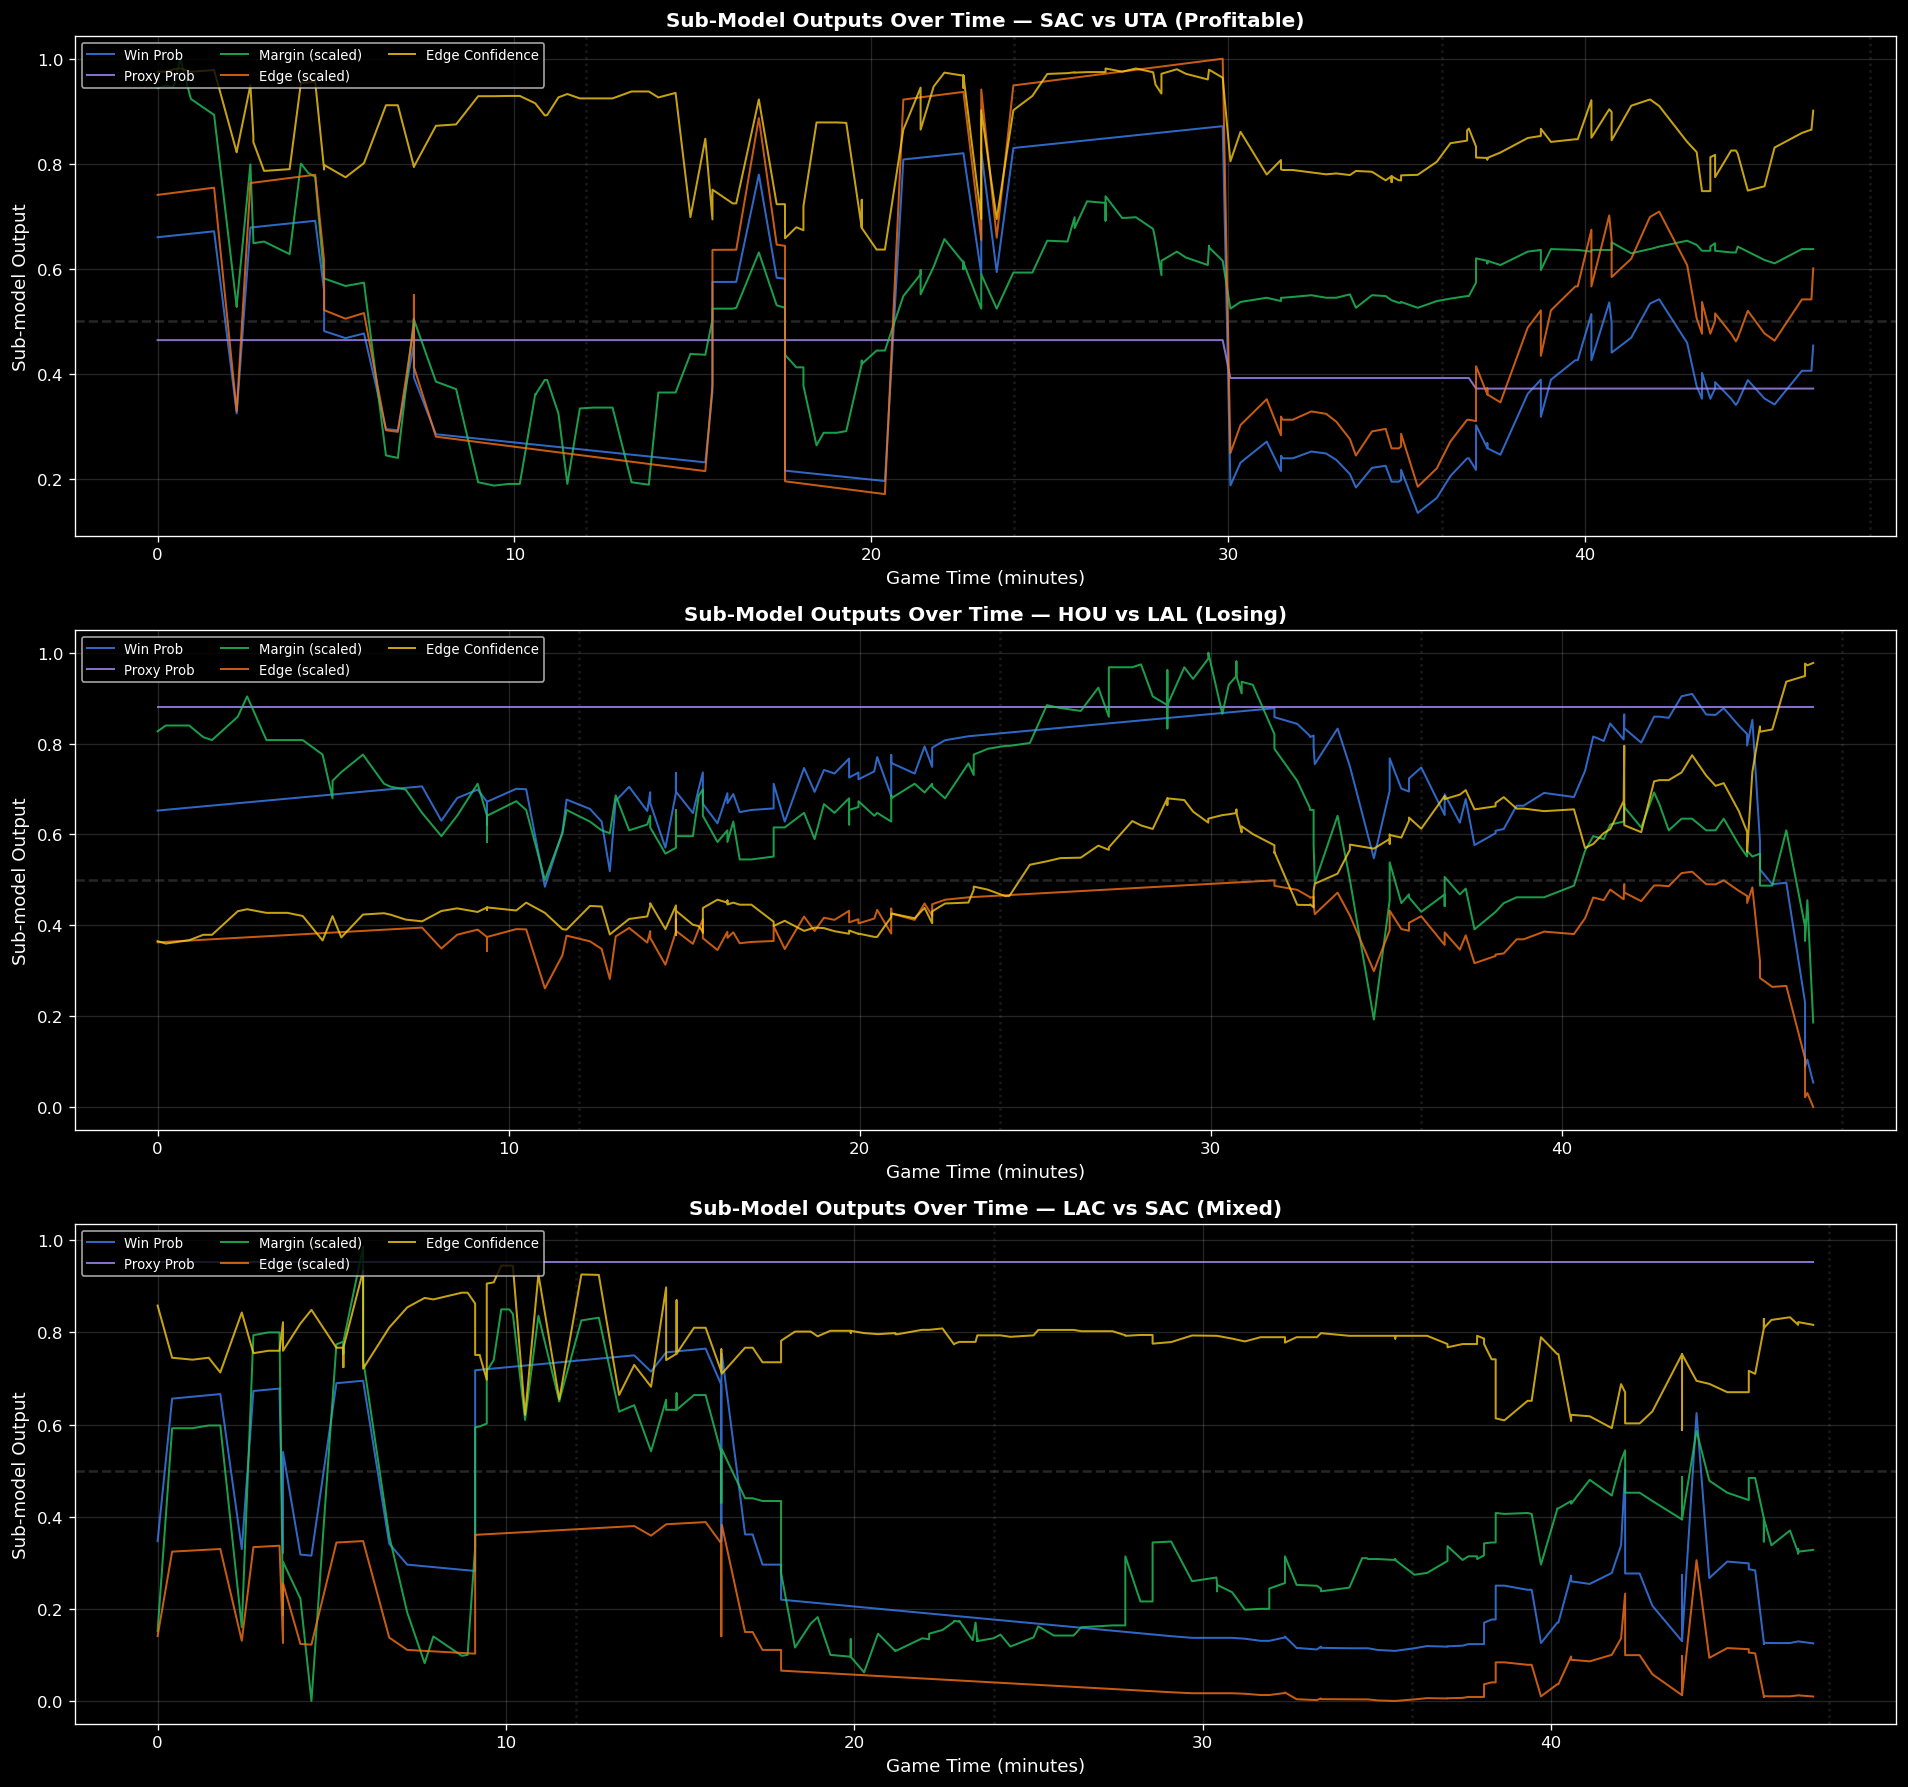

In [33]:
# ── Section 7: Sub-Model Output Decomposition ───────────────────────────────
sub_cols = ["model_win_prob", "model_proxy_prob", "model_margin", "model_edge", "model_edge_confidence"]
sub_labels = ["Win Prob", "Proxy Prob", "Margin", "Edge", "Edge Confidence"]
sub_colors = [BLUE, PURPLE, GREEN, ORANGE, YELLOW]

# ─── Time series for 3 games ───
# Use the same 3 games from Section 3
ts_games = [
    ("0022500982", "SAC vs UTA (Profitable)"),
    ("0022500989", "HOU vs LAL (Losing)"),
    ("0022500975", "LAC vs SAC (Mixed)"),
]

fig, axes = plt.subplots(len(ts_games), 1, figsize=(16, 5 * len(ts_games)))

for idx, (gid, label) in enumerate(ts_games):
    ax = axes[idx]
    gsnap = snapshots[snapshots["game_id"] == gid].copy()
    gsnap = gsnap.sort_values("game_seconds_left", ascending=False)
    total_secs = gsnap["game_seconds_left"].max()
    gsnap["elapsed_min"] = (total_secs - gsnap["game_seconds_left"]) / 60.0

    for col, clabel, color in zip(sub_cols, sub_labels, sub_colors):
        if col in gsnap.columns and gsnap[col].notna().any():
            vals = gsnap[col].values
            # Normalize margin to [0,1] range for comparison
            if col == "model_margin":
                # Scale margin to comparable range: use sigmoid-like scaling
                vals_norm = vals / (np.abs(vals).max() + 1e-9) * 0.5 + 0.5
                ax.plot(gsnap["elapsed_min"], vals_norm, color=color, linewidth=1.2,
                        alpha=0.8, label=f"{clabel} (scaled)")
            elif col == "model_edge":
                vals_norm = vals / (np.abs(vals).max() + 1e-9) * 0.5 + 0.5
                ax.plot(gsnap["elapsed_min"], vals_norm, color=color, linewidth=1.2,
                        alpha=0.8, label=f"{clabel} (scaled)")
            else:
                ax.plot(gsnap["elapsed_min"], vals, color=color, linewidth=1.2,
                        alpha=0.8, label=clabel)

    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3)
    ax.set_ylabel("Sub-model Output")
    ax.set_title(f"Sub-Model Outputs Over Time — {label}", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8, ncol=3)
    ax.grid(alpha=0.15)
    for q_end in [12, 24, 36, 48]:
        ax.axvline(q_end, color="gray", linestyle=":", alpha=0.2)
    ax.set_xlabel("Game Time (minutes)")

plt.tight_layout()
plt.show()

  TICK-TO-TICK VOLATILITY (absolute change per snapshot)
  Sub-Model              Mean |dTick|          Std          Max    N ticks
  ---------------------------------------------------------------------------
  Win Prob                   0.017818     0.062124     0.937600      12022
  Proxy Prob                 0.000091     0.001849     0.072200      12022
  Margin                     0.738937     1.867943    54.400000      12022
  Edge                       0.017881     0.062062     0.937500      12022
  Edge Confidence            0.014496     0.033946     0.485700      12022

  Most volatile sub-model: Margin (avg tick-to-tick swing: 0.738937)



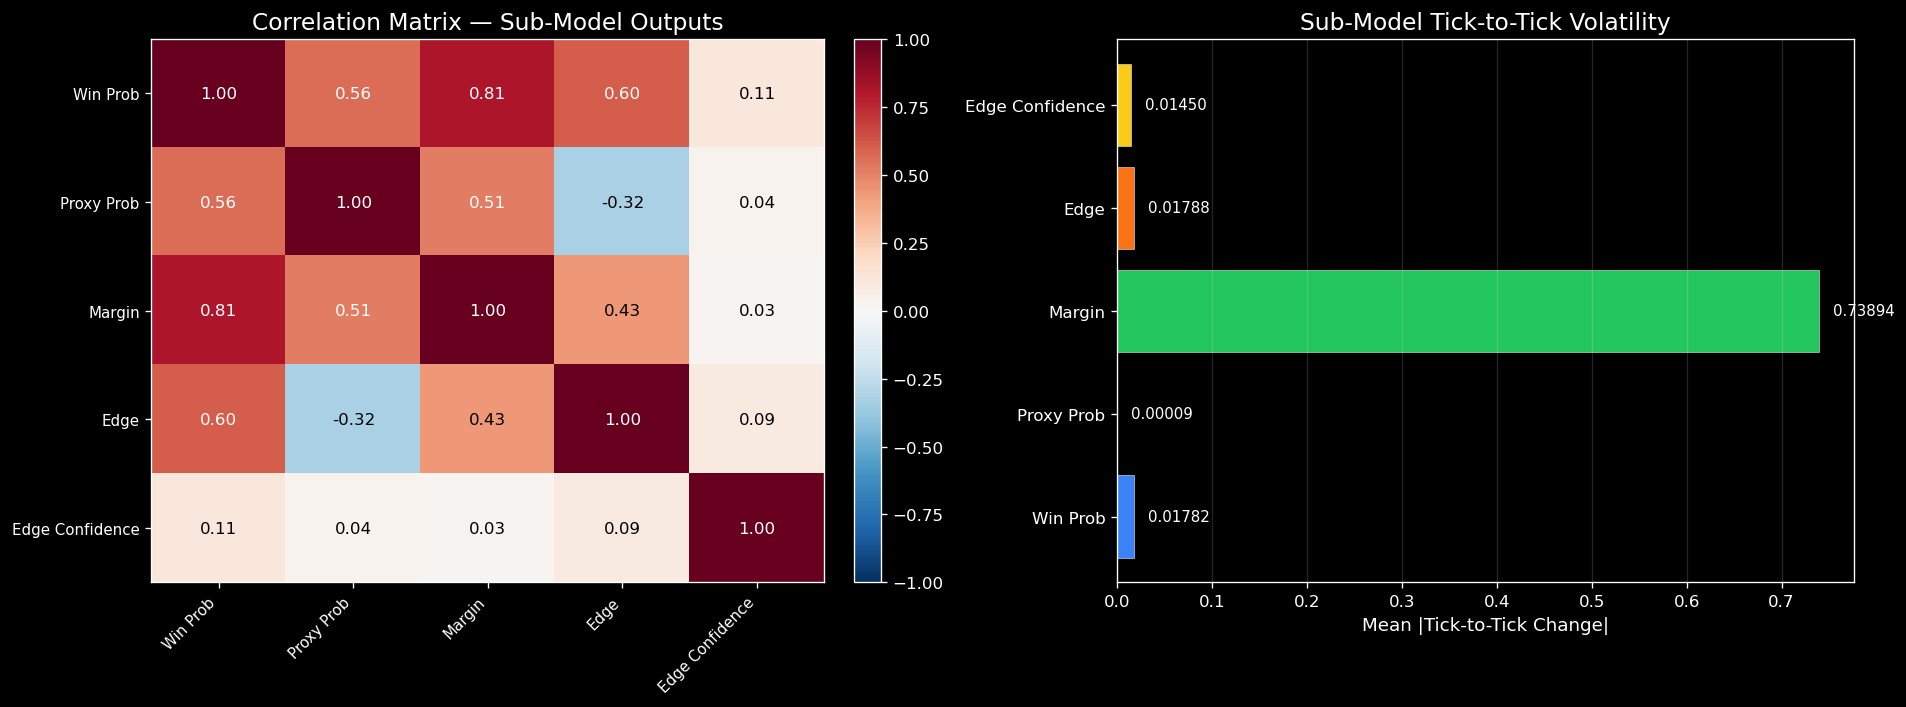


  CORRELATION MATRIX
                       model_win_prob  model_proxy_prob  model_margin  model_edge  model_edge_confidence
model_win_prob                  1.000             0.561         0.807       0.602                  0.113
model_proxy_prob                0.561             1.000         0.508      -0.324                  0.036
model_margin                    0.807             0.508         1.000       0.432                  0.030
model_edge                      0.602            -0.324         0.432       1.000                  0.094
model_edge_confidence           0.113             0.036         0.030       0.094                  1.000


In [34]:
# ── Tick-to-tick volatility & correlation matrix ─────────────────────────────

# Compute tick-to-tick volatility for each sub-model across ALL games
volatility_results = {}
for col, clabel in zip(sub_cols, sub_labels):
    diffs = []
    for gid, grp in snapshots.groupby("game_id"):
        grp_sorted = grp.sort_values("game_seconds_left", ascending=False)
        if col in grp_sorted.columns and grp_sorted[col].notna().sum() > 2:
            vals = grp_sorted[col].dropna().values
            tick_diffs = np.abs(np.diff(vals))
            diffs.extend(tick_diffs.tolist())
    diffs = np.array(diffs)
    volatility_results[clabel] = {
        "mean_abs_change": diffs.mean() if len(diffs) > 0 else 0,
        "std_change": diffs.std() if len(diffs) > 0 else 0,
        "max_change": diffs.max() if len(diffs) > 0 else 0,
        "n_ticks": len(diffs),
    }

print("  TICK-TO-TICK VOLATILITY (absolute change per snapshot)")
print("  " + "=" * 75)
print(f"  {'Sub-Model':<20} {'Mean |dTick|':>14} {'Std':>12} {'Max':>12} {'N ticks':>10}")
print("  " + "-" * 75)
most_volatile = None
max_vol = 0
for clabel, stats in volatility_results.items():
    print(f"  {clabel:<20} {stats['mean_abs_change']:>14.6f} {stats['std_change']:>12.6f} {stats['max_change']:>12.6f} {stats['n_ticks']:>10}")
    if stats["mean_abs_change"] > max_vol:
        max_vol = stats["mean_abs_change"]
        most_volatile = clabel
print("  " + "=" * 75)
print(f"\n  Most volatile sub-model: {most_volatile} (avg tick-to-tick swing: {max_vol:.6f})")
print()

# ─── Correlation matrix between sub-model outputs ───
sub_data = snapshots[sub_cols].dropna()
corr_matrix = sub_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(sub_labels)))
ax.set_yticks(range(len(sub_labels)))
ax.set_xticklabels(sub_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(sub_labels, fontsize=9)
ax.set_title("Correlation Matrix — Sub-Model Outputs")

# Annotate
for i in range(len(sub_labels)):
    for j in range(len(sub_labels)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Bar chart of volatilities
ax = axes[1]
vol_names = list(volatility_results.keys())
vol_vals = [volatility_results[k]["mean_abs_change"] for k in vol_names]
bars = ax.barh(vol_names, vol_vals, color=sub_colors, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Mean |Tick-to-Tick Change|")
ax.set_title("Sub-Model Tick-to-Tick Volatility")
ax.grid(axis="x", alpha=0.15)

# Annotate values
for i, (name, val) in enumerate(zip(vol_names, vol_vals)):
    ax.text(val + max(vol_vals) * 0.02, i, f"{val:.5f}", va="center", fontsize=9, color="white")

plt.tight_layout()
plt.show()

# Print correlation matrix as text
print("\n  CORRELATION MATRIX")
print("  " + "=" * 80)
print(corr_matrix.round(3).to_string())
print("  " + "=" * 80)